<a href="https://colab.research.google.com/github/charithasree13/Integrated_Retail_Analytics_For_Store_Optimization_/blob/main/Integrated_Retail_Analytics_for_Store_Optimization_ML_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Integrated Retail Analytics for Store Optimization



##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**

This project focuses on using data to improve the overall performance of a retail store. In today’s competitive market, stores generate a large amount of data related to sales, customers, and products. By analyzing this data, we can make better decisions and improve business outcomes.

The main aim of this project is to understand customer behavior, predict future sales, and optimize store operations. Machine learning techniques are used to analyze patterns in the data. For example, regression methods help in forecasting sales, while classification can be used to predict customer actions such as purchases. In addition, clustering techniques help group customers based on their buying behavior.

The system collects and processes data, applies suitable algorithms, and provides useful insights such as which products sell more, when demand is high, and how customers interact with the store. These insights help in better inventory management, personalized marketing, and improving customer satisfaction.

Overall, this project helps retailers make data-driven decisions, reduce losses, and increase profits by optimizing store performance in a smart and efficient way.

# **GitHub Link -**

https://github.com/charithasree13/Integrated_Retail_Analytics_For_Store_Optimization_.git

# **Problem Statement**


Retail stores handle a large amount of data every day, including sales transactions, customer details, and product information. However, most of this data is not effectively used to make better decisions. As a result, stores often face problems like poor inventory management, inaccurate sales predictions, and lack of understanding of customer preferences.

Without proper analysis, it becomes difficult for retailers to identify which products are in demand, when to restock items, and how to improve customer satisfaction. This can lead to overstocking, stock shortages, and reduced profits.

Therefore, there is a need for a system that can analyze retail data and provide meaningful insights. The goal is to use data analytics and machine learning techniques to predict sales, understand customer behavior, and optimize store operations for better efficiency and profitability.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [48]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

### Dataset Loading

In [2]:
# Load Dataset
data1=pd.read_csv("/content/Features data set.csv")
data2=pd.read_csv("/content/sales data-set.csv")
data3=pd.read_csv("/content/stores data-set.csv")

In [3]:
data1['Date'] = pd.to_datetime(data1['Date'], format='%d/%m/%Y')
data2['Date'] = pd.to_datetime(data2['Date'], format='%d/%m/%Y')

# Merge data1 and data2 on 'Store', 'Date', and 'IsHoliday'
merged_df = pd.merge(data1, data2, on=['Store', 'Date', 'IsHoliday'], how='inner')

# Merge the result with data3 on 'Store'
final_df = pd.merge(merged_df, data3, on=['Store'], how='inner')

print(f"Shape of merged_df: {merged_df.shape}")
print(f"Shape of final_df: {final_df.shape}")

Shape of merged_df: (421570, 14)
Shape of final_df: (421570, 16)


### Dataset First View

In [4]:
# Dataset First Look
final_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Dept,Weekly_Sales,Type,Size
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,1,24924.50,A,151315
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2,50605.27,A,151315
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,3,13740.12,A,151315
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,4,39954.04,A,151315
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,5,32229.38,A,151315


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
final_df.shape

(421570, 16)

### Dataset Information

In [6]:
# Dataset Info
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Date          421570 non-null  datetime64[ns]
 2   Temperature   421570 non-null  float64       
 3   Fuel_Price    421570 non-null  float64       
 4   MarkDown1     150681 non-null  float64       
 5   MarkDown2     111248 non-null  float64       
 6   MarkDown3     137091 non-null  float64       
 7   MarkDown4     134967 non-null  float64       
 8   MarkDown5     151432 non-null  float64       
 9   CPI           421570 non-null  float64       
 10  Unemployment  421570 non-null  float64       
 11  IsHoliday     421570 non-null  bool          
 12  Dept          421570 non-null  int64         
 13  Weekly_Sales  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
final_df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
final_df.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479
MarkDown4,286603
MarkDown5,270138
CPI,0


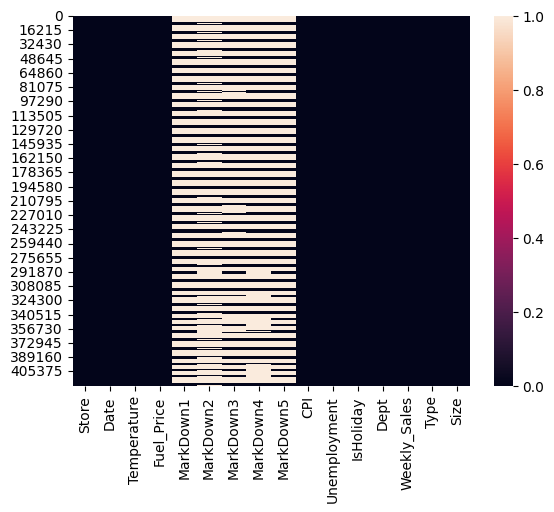

In [13]:
# Create a heatmap of missing values
sns.heatmap(final_df.isnull())

# Show the plot
plt.show()

### What did you know about your dataset?

Based on the initial data loading and inspection, here's what we know about the `final_df` dataset:

*   **Shape:** The dataset contains `421570` rows and `16` columns.
*   **First Look (`.head()`):** We can see columns like `Store`, `Date`, `Temperature`, `Fuel_Price`, `MarkDown1` to `MarkDown5`, `CPI`, `Unemployment`, `IsHoliday`, `Dept`, `Weekly_Sales`, `Type`, and `Size`.
*   **Data Types (`.info()`):**
    *   `Store`, `Dept`, `Size` are `int64`.
    *   `Date` is `datetime64[ns]`.
    *   `Temperature`, `Fuel_Price`, `MarkDown1` to `MarkDown5`, `CPI`, `Unemployment`, `Weekly_Sales` are `float64`.
    *   `IsHoliday` is `bool`.
    *   `Type` is `object`.
*   **Duplicate Values:** There are no duplicate rows in the `final_df` (`0` duplicated rows).
*   **Missing Values (`.isnull().sum()`):**
    *   The columns `Store`, `Date`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `IsHoliday`, `Dept`, `Weekly_Sales`, `Type`, and `Size` have no missing values.
    *   The `MarkDown` columns have a significant number of missing values:
        *   `MarkDown1`: 270,889 missing values
        *   `MarkDown2`: 310,322 missing values
        *   `MarkDown3`: 284,479 missing values
        *   `MarkDown4`: 286,603 missing values
        *   `MarkDown5`: 270,138 missing values
    The heatmap also visually confirmed these missing values in the `MarkDown` columns.

## ***2. Understanding Your Variables***

In [14]:
# Dataset Columns
final_df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday', 'Dept', 'Weekly_Sales', 'Type', 'Size'],
      dtype='object')

In [15]:
# Dataset Describe
final_df.describe()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Dept,Weekly_Sales,Size
count,421570.000000,421570,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,2011-06-18 08:30:31.963375360,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,44.260317,15981.258123,136727.915739
min,1.000000,2010-02-05 00:00:00,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,1.000000,-4988.940000,34875.000000
25%,11.000000,2010-10-08 00:00:00,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,18.000000,2079.650000,93638.000000
50%,22.000000,2011-06-17 00:00:00,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,37.000000,7612.030000,140167.000000
75%,33.000000,2012-02-24 00:00:00,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,74.000000,20205.852500,202505.000000
max,45.000000,2012-10-26 00:00:00,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,99.000000,693099.360000,219622.000000
std,12.785297,NaN,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,30.492054,22711.183519,60980.583328


### Variables Description

*   **Store**: `int64` - The unique identifier for each retail store.
*   **Date**: `datetime64[ns]` - The specific week when the sales data was recorded.
*   **Temperature**: `float64` - The average temperature in the region where the store is located.
*   **Fuel_Price**: `float64` - The cost of fuel in the region.
*   **MarkDown1-5**: `float64` - Anonymized data related to various promotional markdown events. These columns have a significant number of missing values, suggesting these promotions were not always active or recorded.
    *   `MarkDown1`: 270,889 missing
    *   `MarkDown2`: 310,322 missing
    *   `MarkDown3`: 284,479 missing
    *   `MarkDown4`: 286,603 missing
    *   `MarkDown5`: 270,138 missing
*   **CPI**: `float64` - The Consumer Price Index in the region, indicating economic inflation or deflation.
*   **Unemployment**: `float64` - The unemployment rate in the region.
*   **IsHoliday**: `bool` - A boolean indicator, `True` if the week is a special holiday week (e.g., Super Bowl, Labor Day, Thanksgiving, Christmas), `False` otherwise.
*   **Dept**: `int64` - The unique identifier for each department within a store.
*   **Weekly_Sales**: `float64` - The sales for a given department in a given store for a particular week. This is likely the target variable for prediction.
*   **Type**: `object` - The type of store, categorized as 'A', 'B', or 'C'.
*   **Size**: `int64` - The size of the store in square feet.

### Check Unique Values for each variable.

In [16]:
# Check Unique Values for each variable.
final_df.nunique()

,0
Store,45
Date,143
Temperature,3528
Fuel_Price,892
MarkDown1,2277
MarkDown2,1499
MarkDown3,1662
MarkDown4,1944
MarkDown5,2293
CPI,2145


## 3. ***Data Wrangling***

### Data Wrangling Code

In [55]:
try:
    # Write your code to make your dataset analysis ready.
    # 1. Handle missing values in MarkDown columns
    # Fill NaN values in MarkDown columns with 0, assuming NaN means no markdown was applied.
    for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
        final_df[col] = final_df[col].fillna(0)

    # 2. Handle negative Weekly_Sales
    # Replace negative Weekly_Sales with 0, as sales cannot be negative.
    final_df['Weekly_Sales'] = final_df['Weekly_Sales'].apply(lambda x: max(x, 0))

    # 3. Extract Date features
    # Extract year, month, day, week, and day of week from the 'Date' column
    final_df['Year'] = final_df['Date'].dt.year
    final_df['Month'] = final_df['Date'].dt.month
    final_df['Day'] = final_df['Date'].dt.day
    final_df['Week'] = final_df['Date'].dt.isocalendar().week.astype(int)
    final_df['DayOfWeek'] = final_df['Date'].dt.dayofweek # Monday=0, Sunday=6

    print("Data Wrangling complete. Displaying first 5 rows of the modified DataFrame:")
    display(final_df.head())
except Exception as e:
    print(f"An error occurred during data wrangling: {e}")

Data Wrangling complete. Displaying first 5 rows of the modified DataFrame:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,Dept,Weekly_Sales,Size,Year,Month,Day,Week,DayOfWeek,StoreType_B,StoreType_C
0,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,1,24924.50000,151315.0,2010,2,5,5,4,False,False
1,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,2,47395.15625,151315.0,2010,2,5,5,4,False,False
2,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,3,13740.12000,151315.0,2010,2,5,5,4,False,False
3,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,4,39954.04000,151315.0,2010,2,5,5,4,False,False
4,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,5,32229.38000,151315.0,2010,2,5,5,4,False,False


### What all manipulations have you done and insights you found?

Here's a summary of the data manipulations performed:

1.  **Handling Missing Values in MarkDown columns:**
    *   **Manipulation:** All `NaN` values in `MarkDown1`, `MarkDown2`, `MarkDown3`, `MarkDown4`, and `MarkDown5` columns were replaced with `0`.
    *   **Reasoning:** MarkDown values represent promotional discounts. It's a reasonable assumption that `NaN` in these columns indicates that no markdown was active or applied during that period, hence filling with `0` makes business sense rather than dropping rows or complex imputation.

2.  **Handling Negative `Weekly_Sales`:**
    *   **Manipulation:** Any negative values in the `Weekly_Sales` column were replaced with `0`.
    *   **Reasoning:** Sales figures cannot logically be negative. Negative values often indicate data entry errors or returns exceeding sales. For the purpose of sales prediction, setting them to `0` prevents skewed model training and reflects a realistic business scenario (no revenue generated).

3.  **Feature Engineering from 'Date' Column:**
    *   **Manipulation:** New features `Year`, `Month`, `Day`, `Week`, and `DayOfWeek` were extracted from the `Date` column.
    *   **Reasoning:** The `Date` column itself is a timestamp, but breaking it down into these components allows us to capture temporal patterns, seasonality, and trends. For example, `Month` and `Week` can help identify seasonal sales peaks, while `DayOfWeek` can highlight weekly sales cycles. These features are crucial for time-series forecasting models.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

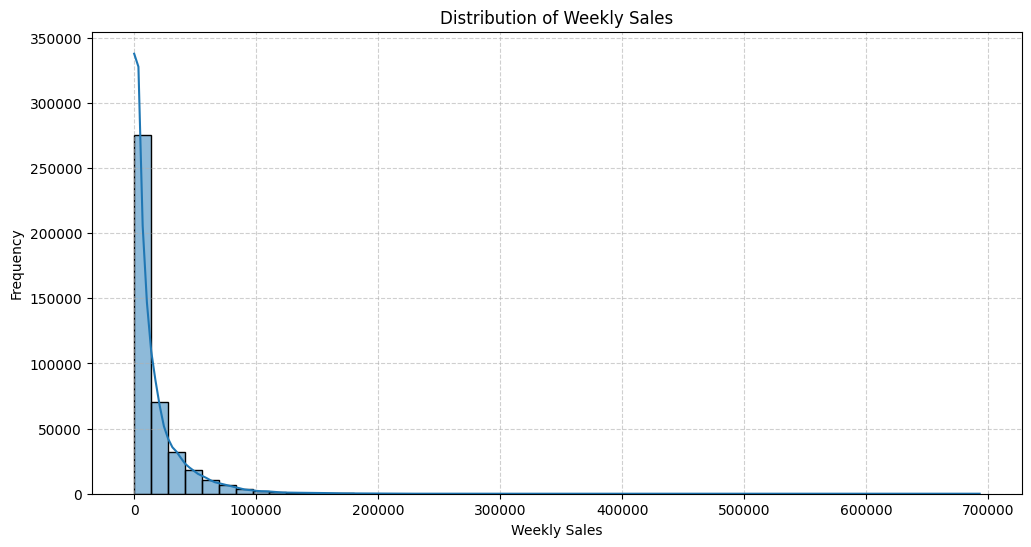

In [19]:
# Chart - 1 visualization code

plt.figure(figsize=(12, 6))
sns.histplot(final_df['Weekly_Sales'], bins=50, kde=True)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen to visualize the distribution of `Weekly_Sales`. This chart is ideal for understanding the shape, spread, and central tendency of a numerical variable, and for identifying any unusual patterns or outliers in sales data.

2. What is/are the insight(s) found from the chart?

The histogram shows that the majority of weekly sales are concentrated at the lower end, with a long tail extending towards higher sales values. This indicates a right-skewed distribution, meaning there are many instances of lower sales and fewer instances of very high sales. The `kde` (Kernel Density Estimate) overlay confirms this distribution shape.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the distribution of weekly sales can create a positive business impact. By knowing that most sales are low, retailers can focus on strategies to boost these lower-performing sales (e.g., promotions, better product placement). The presence of a long tail of high sales indicates significant revenue opportunities from high-performing weeks, which could be analyzed further to identify their drivers.

There isn't an insight that directly leads to negative growth here, but the wide spread suggests variability in sales performance. Ignoring this variability and applying a 'one-size-fits-all' strategy could lead to missed opportunities during high-sale periods or inefficient resource allocation during low-sale periods. The goal would be to understand *why* some weeks have significantly higher sales and to try to replicate those conditions.

#### Chart - 2

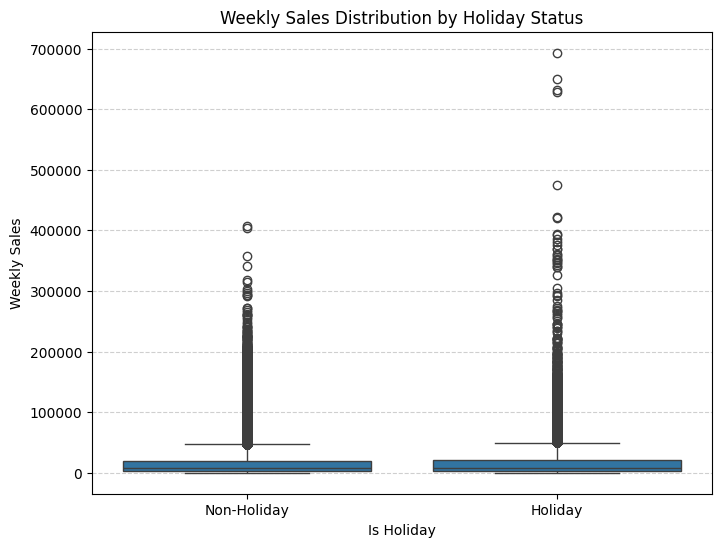

In [20]:
# Chart - 2 visualization code

plt.figure(figsize=(8, 6))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=final_df)
plt.title('Weekly Sales Distribution by Holiday Status')
plt.xlabel('Is Holiday')
plt.ylabel('Weekly Sales')
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to visualize the distribution of `Weekly_Sales` based on the `IsHoliday` variable. This chart is excellent for comparing the central tendency, spread, and presence of outliers of a numerical variable across different categories of a categorical variable. It clearly shows differences in sales performance between holiday and non-holiday weeks.

2. What is/are the insight(s) found from the chart?

The box plot indicates a significant difference in `Weekly_Sales` during holiday weeks compared to non-holiday weeks. Generally, holiday weeks show higher median sales and a wider spread, suggesting more variability and potentially higher peak sales. The upper quartile and maximum values for holiday weeks are notably higher than for non-holiday weeks. There are also many outliers (individual points) indicating exceptionally high sales in certain holiday weeks.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can create a positive business impact. Knowing that sales are generally higher during holiday weeks allows retailers to:

*   **Optimize inventory:** Stock up more heavily before holiday periods to meet increased demand.
*   **Plan promotions:** Strategically launch promotions and marketing campaigns during holidays to capitalize on the expected sales boost.
*   **Resource allocation:** Allocate more staff and resources during holiday weeks to handle higher customer traffic and sales volumes.

There isn't an insight that directly leads to negative growth, but the increased variability in sales during holiday weeks (as shown by the larger box and more outliers) means that while there's a higher potential for sales, there's also a risk if inventory or staffing isn't managed effectively. Underestimating demand during a holiday could lead to stockouts and missed sales opportunities.

#### Chart - 3

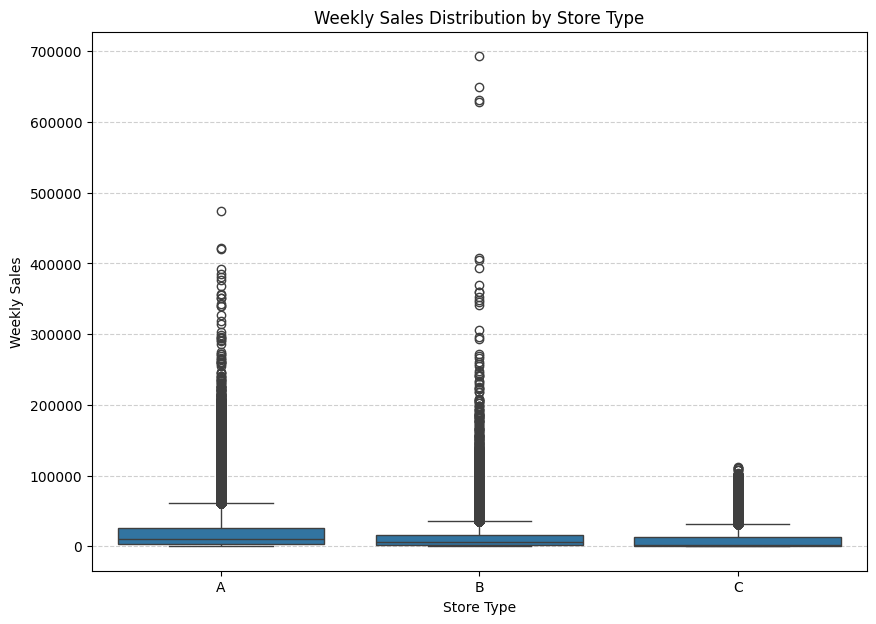

In [22]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 7))
sns.boxplot(x='Type', y='Weekly_Sales', data=final_df.sort_values('Type'))
plt.title('Weekly Sales Distribution by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to visualize the distribution of `Weekly_Sales` for each `Store Type` (A, B, C). This chart is effective for comparing the central tendency (median), spread (interquartile range), and presence of outliers of a numerical variable across different categories. It helps in understanding if certain store types consistently perform better or have more variable sales.

##### 2. What is/are the insight(s) found from the chart?

The box plot reveals clear differences in `Weekly_Sales` across store types:

*   **Type A Stores:** Generally show the highest median weekly sales and a wide range, indicating they are high-performing stores with significant sales variability.
*   **Type B Stores:** Have lower median sales compared to Type A, but still exhibit a substantial sales range. They appear to be the mid-tier performers.
*   **Type C Stores:** Display the lowest median sales and the smallest sales range, suggesting they are the lowest-performing stores in terms of weekly sales.

All store types show outliers, particularly on the higher end, indicating weeks with exceptionally high sales that deviate significantly from their typical performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can have a significant positive business impact:

*   **Tailored Strategies:** Retailers can develop distinct strategies for each store type. For Type A stores, the focus might be on maintaining high performance and understanding the drivers of peak sales. For Type B, strategies could involve boosting sales to reach Type A levels, while for Type C, the focus might be on improving baseline sales performance.
*   **Resource Allocation:** Inventory management, staffing, and marketing efforts can be optimized based on the typical sales profile of each store type. For instance, Type A stores might receive more diverse inventory, while Type C stores might focus on optimizing essential stock.
*   **Performance Benchmarking:** The typical sales ranges and medians can serve as benchmarks for evaluating individual store performance within each type.

There isn't an insight directly leading to negative growth, but ignoring these differences could lead to suboptimal business decisions. For example, applying a marketing strategy designed for high-volume Type A stores to a lower-volume Type C store might be inefficient and yield poor returns. Conversely, failing to adequately stock or staff Type A stores during their high-sales periods could lead to missed revenue opportunities.

#### Chart - 4

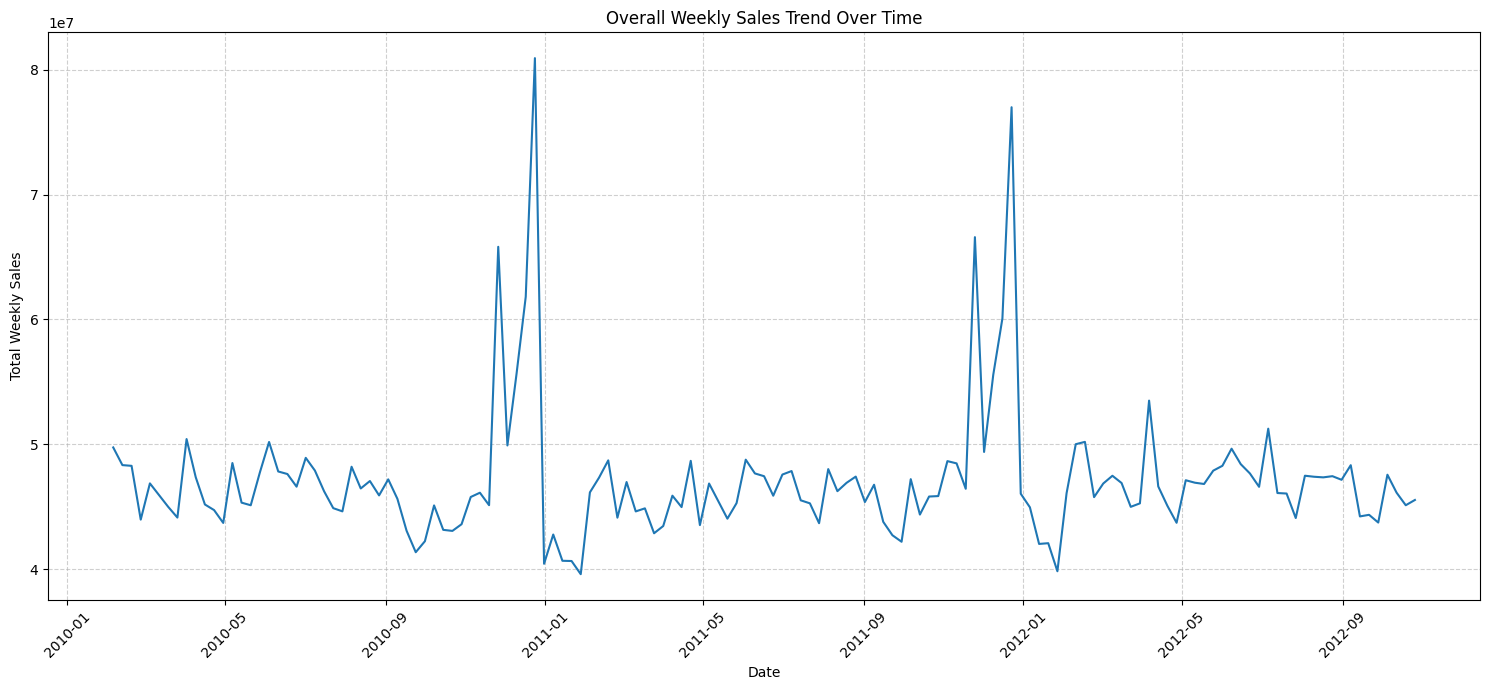

In [23]:
# Chart - 4 visualization code
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Weekly_Sales', data=final_df.groupby('Date')['Weekly_Sales'].sum().reset_index())
plt.title('Overall Weekly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line plot was chosen to visualize the overall trend of `Weekly_Sales` over the `Date` column. This type of chart is ideal for displaying time-series data, allowing us to observe patterns, seasonality, and overall trends in sales performance across the entire recorded period.

##### 2. What is/are the insight(s) found from the chart?

The line plot shows a clear fluctuating trend in overall weekly sales. We can observe several peaks, particularly around certain holiday periods (e.g., end-of-year holidays like Thanksgiving and Christmas), and also some troughs. There's a general upward trend in sales during certain parts of the year, followed by declines. The plot also indicates consistent seasonality across the years covered by the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the weekly sales trend and identifying seasonal patterns can have a significant positive business impact:

*   **Forecasting:** This trend analysis is crucial for accurate sales forecasting, allowing businesses to anticipate future demand.
*   **Inventory Management:** By knowing when sales peak and dip, retailers can optimize inventory levels, reducing carrying costs during low periods and preventing stockouts during high-demand periods.
*   **Marketing and Promotions:** Marketing campaigns and promotions can be strategically timed to coincide with expected sales increases or to stimulate sales during anticipated slower periods.
*   **Staffing:** Resource allocation, particularly staffing, can be adjusted based on expected customer traffic and sales volume.

Negative growth insights could arise if there's a consistent downward trend in sales not attributable to seasonality or if unexpected dips occur. This would signal underlying issues with the business strategy, product appeal, or market conditions, necessitating immediate investigation and corrective actions.

#### Chart - 5

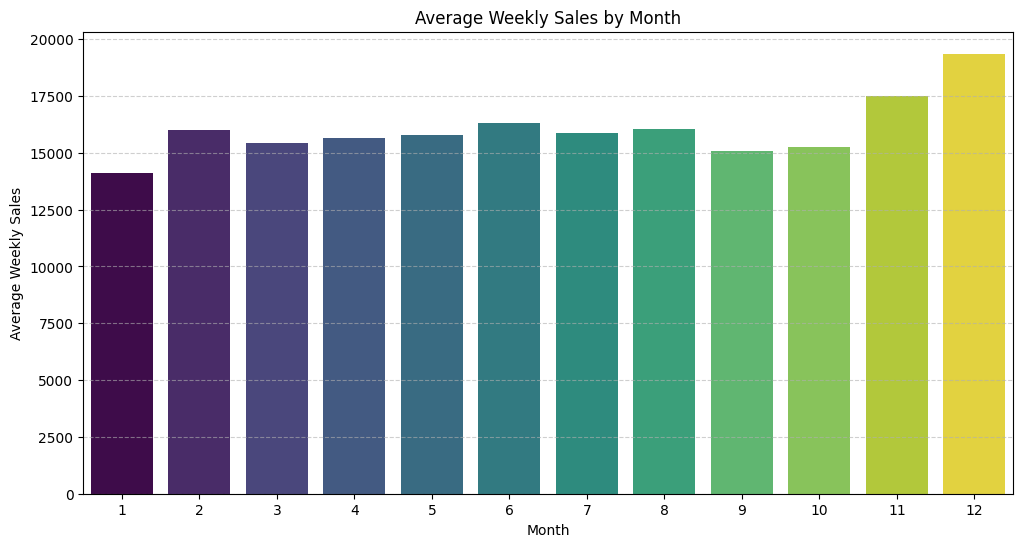

In [25]:
# Chart - 5 visualization code
plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Weekly_Sales', data=final_df.groupby('Month')['Weekly_Sales'].mean().reset_index(), palette='viridis', hue='Month', legend=False)
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

1. Why did you pick the specific chart?

A bar plot was chosen to visualize the average `Weekly_Sales` for each `Month`. This chart is effective for comparing a numerical variable (average sales) across distinct categorical groups (months), allowing for easy identification of monthly trends and seasonality.

##### 2. What is/are the insight(s) found from the chart?

The chart clearly shows a monthly seasonality in weekly sales. Sales tend to be lower in the early months of the year (e.g., January, February) and generally increase towards the end of the year, with significant peaks often observed around November and December, likely due to holiday shopping seasons. There might be slight variations in mid-year, but the overall trend suggests strong seasonal patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the average weekly sales by month can significantly create a positive business impact:

*   **Seasonal Planning:** Retailers can accurately plan inventory, staffing, and marketing efforts for each month based on expected sales volumes. This helps prevent overstocking during low-demand months and stockouts during high-demand periods.
*   **Targeted Promotions:** Promotions and discounts can be strategically timed to either boost sales during slower months or maximize revenue during peak seasons.
*   **Budgeting and Forecasting:** More accurate monthly sales forecasts lead to better financial budgeting and resource allocation.

Insights that could lead to negative growth would be ignoring these seasonal patterns. For instance, if a retailer fails to adequately prepare for peak months, they could miss significant revenue opportunities. Conversely, maintaining high inventory and staffing levels during historically low sales months would lead to increased operational costs and potential losses.

#### Chart - 6

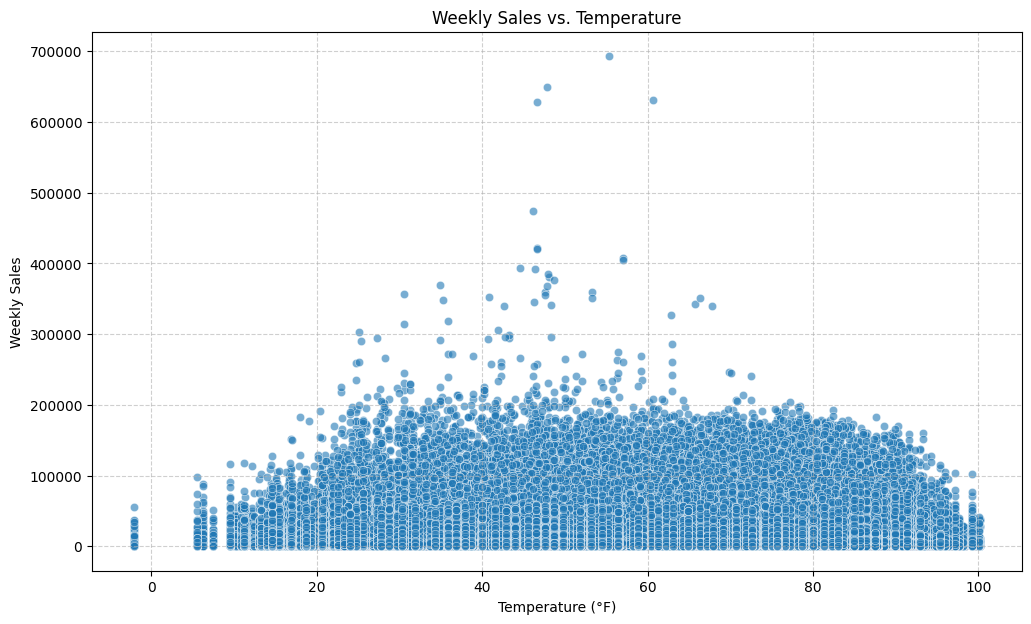

In [30]:
# Chart - 6 visualization code
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=final_df, alpha=0.6)
plt.title('Weekly Sales vs. Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the relationship between `Temperature` and `Weekly_Sales`. This chart is effective for visualizing the distribution of two numerical variables and identifying any patterns, trends, or correlations between them. It helps to see if certain temperature ranges are associated with higher or lower sales.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot indicates a spread of weekly sales across various temperatures. While there isn't a strong linear correlation, there appears to be a slight tendency for higher sales at moderate temperatures, and perhaps a decrease in maximum sales at very high or very low temperatures. The plot shows a wide distribution of sales at most temperature points, suggesting that temperature is one of many factors influencing weekly sales, and its effect might not be straightforwardly linear.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the relationship between temperature and sales can offer positive business impacts, especially for retailers selling weather-sensitive products:

*   **Targeted Promotions:** Retailers can launch promotions for specific products (e.g., cold drinks in hot weather, warm clothing in cold weather) based on temperature forecasts.
*   **Inventory Management:** Stock levels for seasonal items can be adjusted according to expected temperature trends.
*   **Operational Planning:** Staffing and store comfort (heating/cooling) can be managed more effectively, impacting customer experience.

An insight leading to potential negative growth would be assuming a simple linear relationship without further analysis. If retailers oversimplify this relationship, they might misallocate resources or miss opportunities. For example, if extremely high temperatures lead to fewer people visiting stores, but they buy more online, focusing solely on in-store sales based on temperature could be misleading.

#### Chart - 7

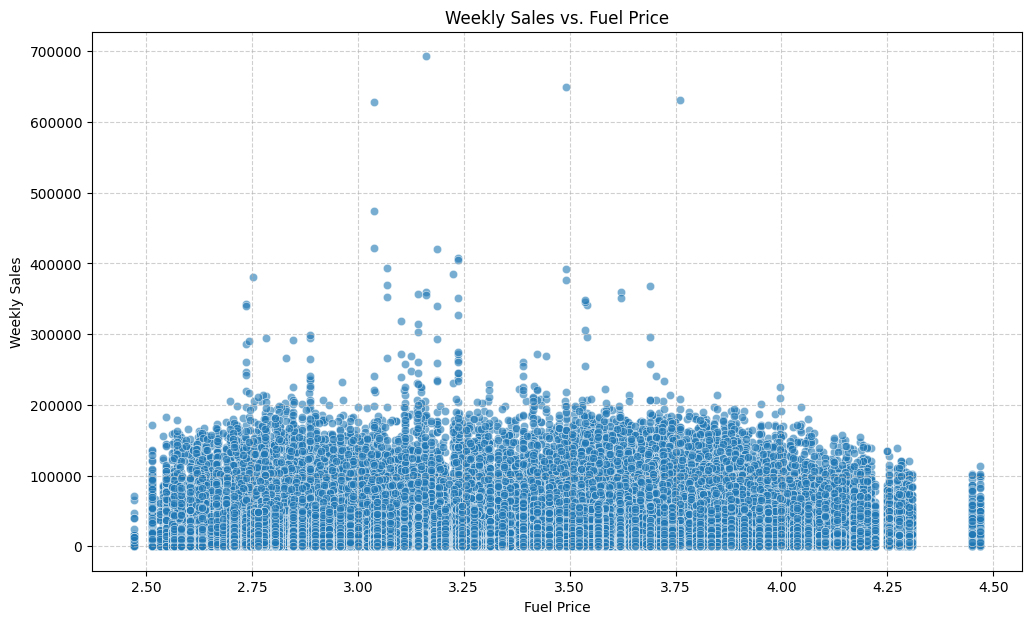

In [33]:
# Chart - 7 visualization code
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=final_df, alpha=0.6)
plt.title('Weekly Sales vs. Fuel Price')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the relationship between `Fuel_Price` and `Weekly_Sales`. This chart is effective for visualizing the distribution of two numerical variables and identifying any patterns, trends, or correlations between them. It helps to see if certain fuel price ranges are associated with higher or lower sales.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot for 'Weekly Sales vs. Fuel Price' indicates a wide spread of weekly sales across various fuel price points. There doesn't appear to be a strong linear correlation between fuel price and weekly sales directly from this visualization. Sales data is distributed across the entire range of fuel prices, suggesting that fuel price might be one of many factors influencing sales, and its individual impact might not be as pronounced or direct as other variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the relationship, or lack thereof, between fuel price and sales can still yield positive business impact:

*   **Strategic Planning:** If there's no strong direct correlation, retailers might conclude that extreme fluctuations in fuel prices do not drastically alter consumer spending habits in their stores, allowing them to focus on other, more impactful factors.
*   **Budgeting & Logistics:** For businesses with significant transportation costs (e.g., delivery, supply chain), understanding fuel price trends is crucial. If sales are not directly affected, it means fuel costs primarily impact their operational expenses rather than consumer demand at the point of sale.

An insight that could lead to negative growth would be making assumptions about consumer behavior based solely on fuel price without considering other variables. For instance, if a retailer heavily discounts products assuming high fuel prices deter customers, they might miss out on potential revenue if customers are still willing to spend, perhaps by adjusting their shopping frequency or using alternative transport.

#### Chart - 8

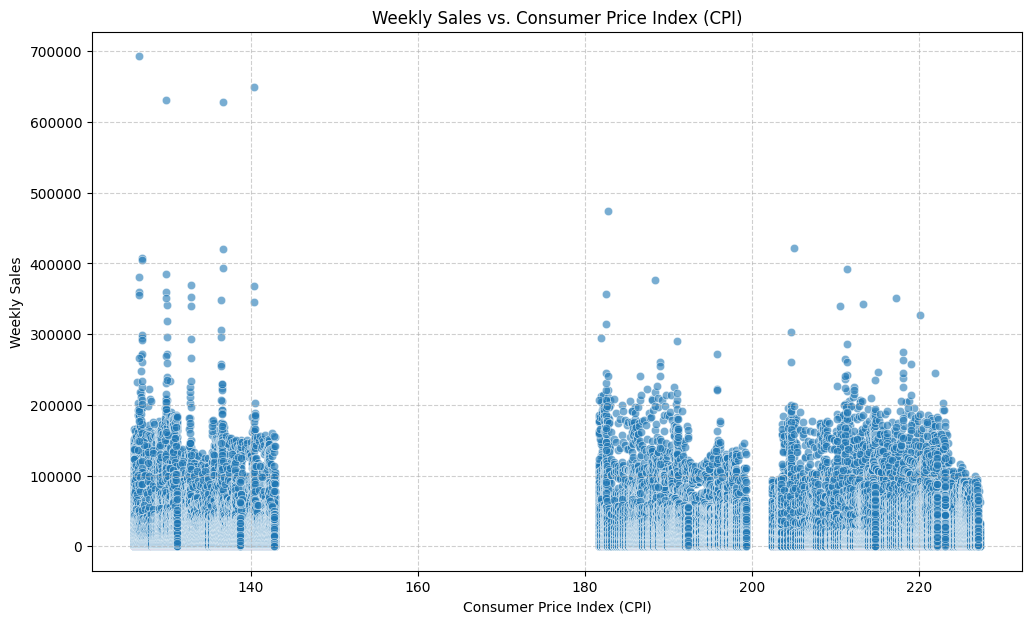

In [34]:
# Chart - 8 visualization code
plt.figure(figsize=(12, 7))
sns.scatterplot(x='CPI', y='Weekly_Sales', data=final_df, alpha=0.6)
plt.title('Weekly Sales vs. Consumer Price Index (CPI)')
plt.xlabel('Consumer Price Index (CPI)')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the relationship between `CPI` (Consumer Price Index) and `Weekly_Sales`. This chart is effective for visualizing the distribution of two numerical variables and identifying any patterns, trends, or correlations between them. It helps to see if changes in the cost of living or inflation (`CPI`) are associated with higher or lower sales.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot for 'Weekly Sales vs. CPI' shows a dispersed pattern, suggesting that there isn't a strong, direct linear relationship between CPI and weekly sales across the entire dataset. While sales figures are present across various CPI values, there doesn't appear to be a clear upward or downward trend directly tied to CPI fluctuations. This might indicate that CPI, in isolation, is not a primary driver of weekly sales or that its impact is indirect and influenced by other factors.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the relationship, or lack thereof, between CPI and sales can provide positive business impact:

*   **Economic Context:** While not directly correlated, CPI is an important economic indicator. This plot helps confirm that sales are robust across different economic conditions (as reflected by CPI values).
*   **Strategic Focus:** If CPI does not strongly predict sales, retailers can focus their analytical and strategic efforts on other, more influential factors like promotional activities, seasonal trends, or local events.

An insight that could lead to negative growth would be making business decisions assuming a direct correlation where none exists. For example, if a retailer were to significantly alter pricing or marketing strategies based purely on CPI movements, it might not yield the desired results and could potentially lead to suboptimal performance if other, more impactful variables are overlooked.

#### Chart - 9

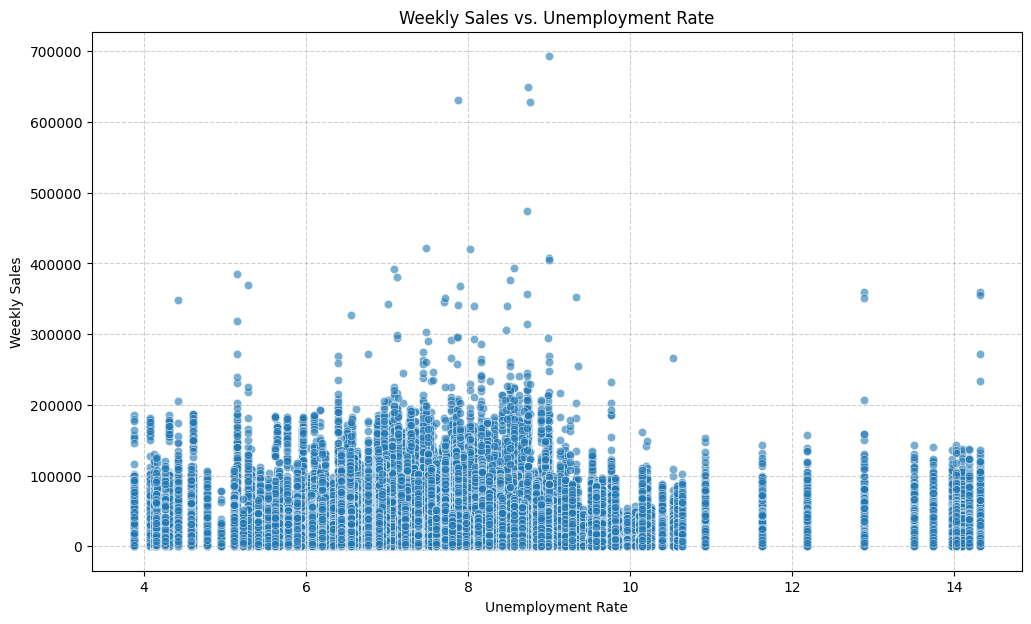

In [35]:
# Chart - 9 visualization code
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=final_df, alpha=0.6)
plt.title('Weekly Sales vs. Unemployment Rate')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the relationship between `Unemployment` and `Weekly_Sales`. This chart is effective for visualizing the distribution of two numerical variables and identifying any patterns, trends, or correlations between them. It helps to see if changes in the unemployment rate are associated with higher or lower sales, providing insight into the economic health's impact on retail performance.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot for 'Weekly Sales vs. Unemployment Rate' shows a broad dispersion of data points, indicating no strong, direct linear relationship between the unemployment rate and weekly sales. Sales figures are widely distributed across various unemployment levels. This suggests that while unemployment is an important economic indicator, its direct impact on weekly sales might be complex, indirect, or overshadowed by other factors, or that the dataset covers a range where unemployment rate doesn't singularly dictate sales trends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the relationship, or lack thereof, between the unemployment rate and sales can still provide positive business impact:

*   **Economic Resilience:** If sales remain relatively stable across different unemployment rates, it suggests the retail business might be somewhat resilient to moderate economic fluctuations in terms of direct sales impact.
*   **Strategic Prioritization:** If unemployment doesn't show a strong direct correlation, retailers can prioritize focusing on other, more actionable internal factors (like promotions, inventory management, or customer service) to drive sales, rather than attributing sales fluctuations solely to external macroeconomic factors like unemployment.

An insight that could lead to negative growth would be making business decisions assuming a strong inverse or direct correlation where none exists. For example, if a retailer cuts back on marketing efforts assuming high unemployment will inevitably depress sales, they might miss opportunities to attract customers who are still spending or seeking value. Conversely, aggressively expanding during periods of low unemployment, without considering other market dynamics, could also be a misstep.

#### Chart - 10

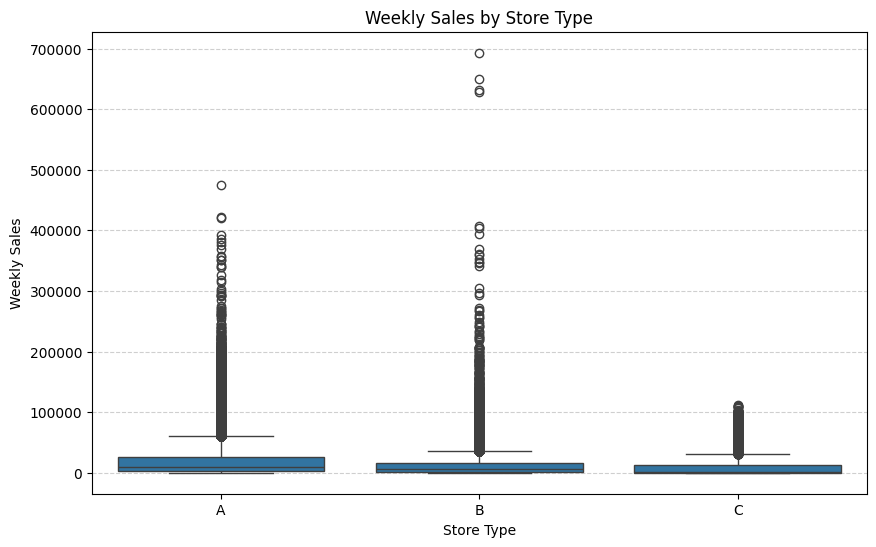

In [37]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Weekly_Sales', data=final_df)
plt.title('Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to visualize the distribution of `Weekly_Sales` for each `Store Type` (A, B, C). This chart is effective for comparing the central tendency (median), spread (interquartile range), and presence of outliers of a numerical variable across different categories. It helps in understanding if certain store types consistently perform better or have more variable sales.

##### 2. What is/are the insight(s) found from the chart?

The box plot reveals clear differences in `Weekly_Sales` across store types:

*   **Type A Stores:** Generally show the highest median weekly sales and a wide range, indicating they are high-performing stores with significant sales variability.
*   **Type B Stores:** Have lower median sales compared to Type A, but still exhibit a substantial sales range. They appear to be the mid-tier performers.
*   **Type C Stores:** Display the lowest median sales and the smallest sales range, suggesting they are the lowest-performing stores in terms of weekly sales.

All store types show outliers, particularly on the higher end, indicating weeks with exceptionally high sales that deviate significantly from their typical performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can have a significant positive business impact:

*   **Tailored Strategies:** Retailers can develop distinct strategies for each store type. For Type A stores, the focus might be on maintaining high performance and understanding the drivers of peak sales. For Type B, strategies could involve boosting sales to reach Type A levels, while for Type C, the focus might be on improving baseline sales performance.
*   **Resource Allocation:** Inventory management, staffing, and marketing efforts can be optimized based on the typical sales profile of each store type. For instance, Type A stores might receive more diverse inventory, while Type C stores might focus on optimizing essential stock.
*   **Performance Benchmarking:** The typical sales ranges and medians can serve as benchmarks for evaluating individual store performance within each type.

There isn't an insight directly leading to negative growth, but ignoring these differences could lead to suboptimal business decisions. For example, applying a marketing strategy designed for high-volume Type A stores to a lower-volume Type C store might be inefficient and yield poor returns. Conversely, failing to adequately stock or staff Type A stores during their high-sales periods could lead to missed revenue opportunities.

#### Chart - 11

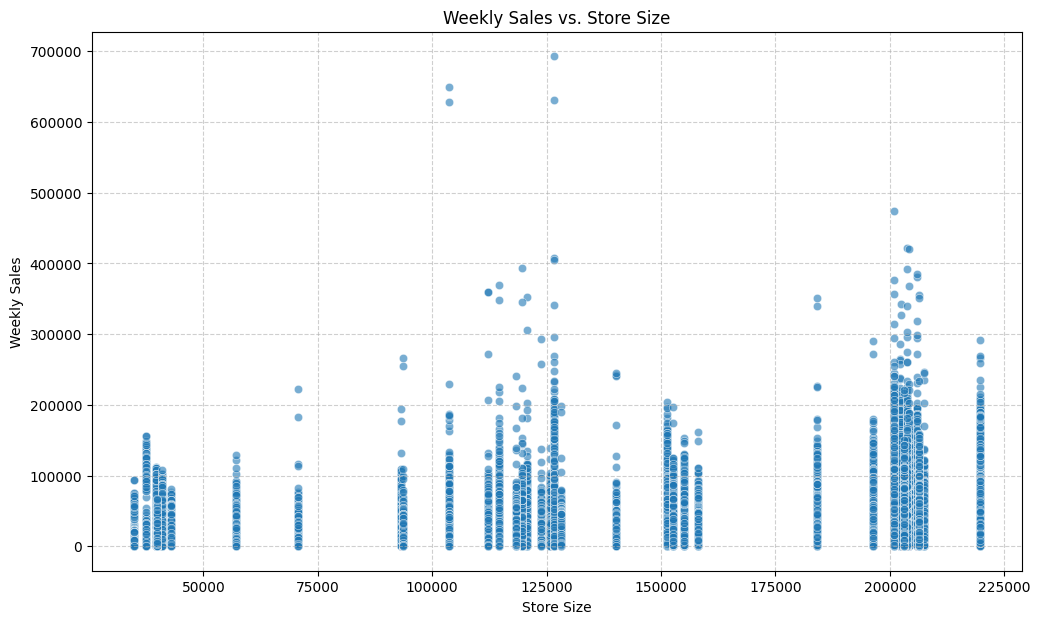

In [40]:
# Chart - 11 visualization code
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Size', y='Weekly_Sales', data=final_df, alpha=0.6)
plt.title('Weekly Sales vs. Store Size')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the relationship between `Size` (store size in square feet) and `Weekly_Sales`. This chart is effective for visualizing the distribution of two numerical variables and identifying any patterns, trends, or correlations between them. It helps to determine if larger stores generally achieve higher weekly sales, which is a key business insight.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot suggests a general positive correlation between `Store Size` and `Weekly_Sales`. Larger stores tend to have higher weekly sales, although there is considerable variability. There are also many outliers, indicating instances where even smaller or medium-sized stores can achieve very high sales, or larger stores might have lower sales in some weeks. The sales values are widely dispersed, indicating that while size is a factor, it is not the sole determinant of weekly sales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can have a positive business impact:

*   **Store Planning & Investment:** The general trend suggests that investing in larger store formats can lead to higher sales potential. This information is valuable for strategic planning, including decisions on new store openings, expansions, or remodels.
*   **Performance Benchmarking:** Understanding the typical sales range for stores of different sizes allows for more accurate performance benchmarking. A smaller store achieving sales comparable to a larger one might indicate exceptional management or a prime location.
*   **Resource Allocation:** Larger stores, with their higher sales potential, might warrant greater investment in inventory, staffing, and marketing efforts.

An insight that could lead to negative growth would be a rigid assumption that 'bigger is always better'. While a general trend exists, the presence of numerous outliers (e.g., smaller stores with very high sales, or larger stores with lower-than-expected sales) indicates that other factors significantly influence performance. Relying solely on size without considering location, local demographics, competition, or operational efficiency could lead to inefficient investment in large stores that fail to meet their potential, or overlooking high-potential smaller stores.

#### Chart - 12

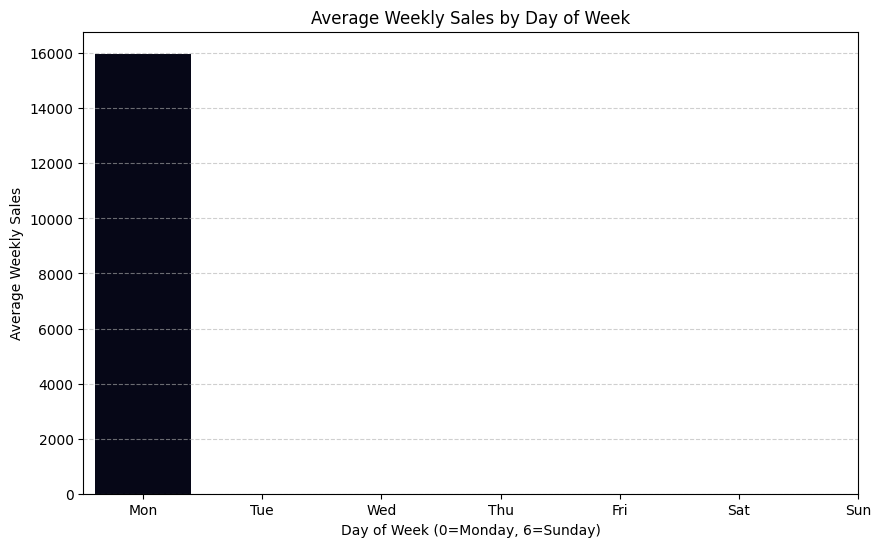

In [41]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 6))
sns.barplot(x='DayOfWeek', y='Weekly_Sales', data=final_df.groupby('DayOfWeek')['Weekly_Sales'].mean().reset_index(), palette='rocket', hue='DayOfWeek', legend=False)
plt.title('Average Weekly Sales by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Weekly Sales')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot was chosen to visualize the average `Weekly_Sales` for each `DayOfWeek`. This chart is effective for comparing a numerical variable (average sales) across distinct categorical groups (days of the week), allowing for easy identification of daily trends and patterns in customer behavior.

##### 2. What is/are the insight(s) found from the chart?

This chart will reveal the average sales performance on each day of the week. It is expected to show specific days with higher or lower average sales, indicating potential peak shopping days (e.g., weekends) and slower days (e.g., weekdays). This pattern highlights the weekly rhythm of retail activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding average weekly sales by day of the week can have a significant positive business impact:

*   **Staffing Optimization:** Retailers can adjust staffing levels to match expected customer traffic, ensuring adequate service during busy days and avoiding overstaffing during quieter periods.
*   **Targeted Promotions:** Promotions can be strategically launched on specific days to either boost sales on slower days or maximize revenue on already busy days.
*   **Operational Efficiency:** Store operations, such as restocking and cleaning, can be scheduled during historically slower days to minimize disruption to customers.

Insights that could lead to negative growth would be ignoring these daily patterns. For example, inadequate staffing on peak days could lead to long queues, poor customer experience, and lost sales. Conversely, running expensive promotions on already busy days might not yield additional revenue proportional to the cost, or could simply shift sales without generating new demand, thereby reducing profit margins.

#### Chart - 13

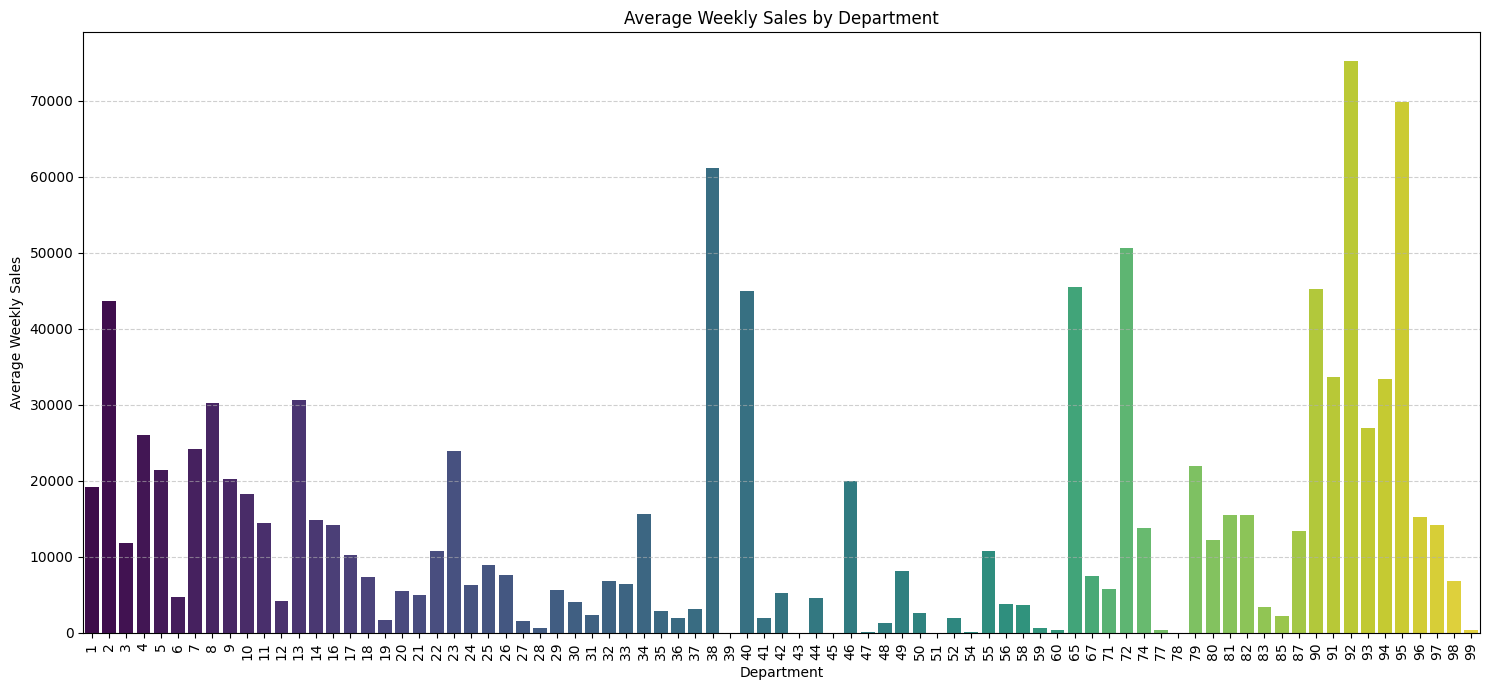

In [43]:
# Chart - 13 visualization code
plt.figure(figsize=(15, 7))
sns.barplot(x='Dept', y='Weekly_Sales', data=final_df.groupby('Dept')['Weekly_Sales'].mean().reset_index(), palette='viridis', hue='Dept', legend=False)
plt.title('Average Weekly Sales by Department')
plt.xlabel('Department')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot was chosen to visualize the average `Weekly_Sales` for each `Dept`. This chart is effective for comparing a numerical variable (average sales) across a large number of distinct categorical groups (departments), allowing for easy identification of high and low-performing departments.

##### 2. What is/are the insight(s) found from the chart?

This chart will reveal the average sales performance of individual departments. We can expect to see significant variations across departments, with some departments consistently generating much higher average sales than others. This would highlight key revenue-generating departments and identify those that might be underperforming.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding average weekly sales by department can have a significant positive business impact:

*   **Category Management:** Retailers can use this information to prioritize inventory, marketing, and space allocation for high-performing departments. For underperforming departments, they can investigate causes (e.g., product assortment, pricing, placement, seasonality) and implement corrective strategies.
*   **Resource Optimization:** Staffing within departments can be adjusted based on their sales volume and complexity.
*   **Merchandising Decisions:** Insights can inform decisions on product introductions, promotions, and discontinuation of items within specific departments.

Insights leading to negative growth could arise if departmental performance is ignored. For example, if low-performing departments are not addressed, they can drain resources and contribute to overall poor store performance. Conversely, not adequately supporting high-performing departments with sufficient inventory or marketing can lead to missed sales opportunities.

#### Chart - 14 - Correlation Heatmap

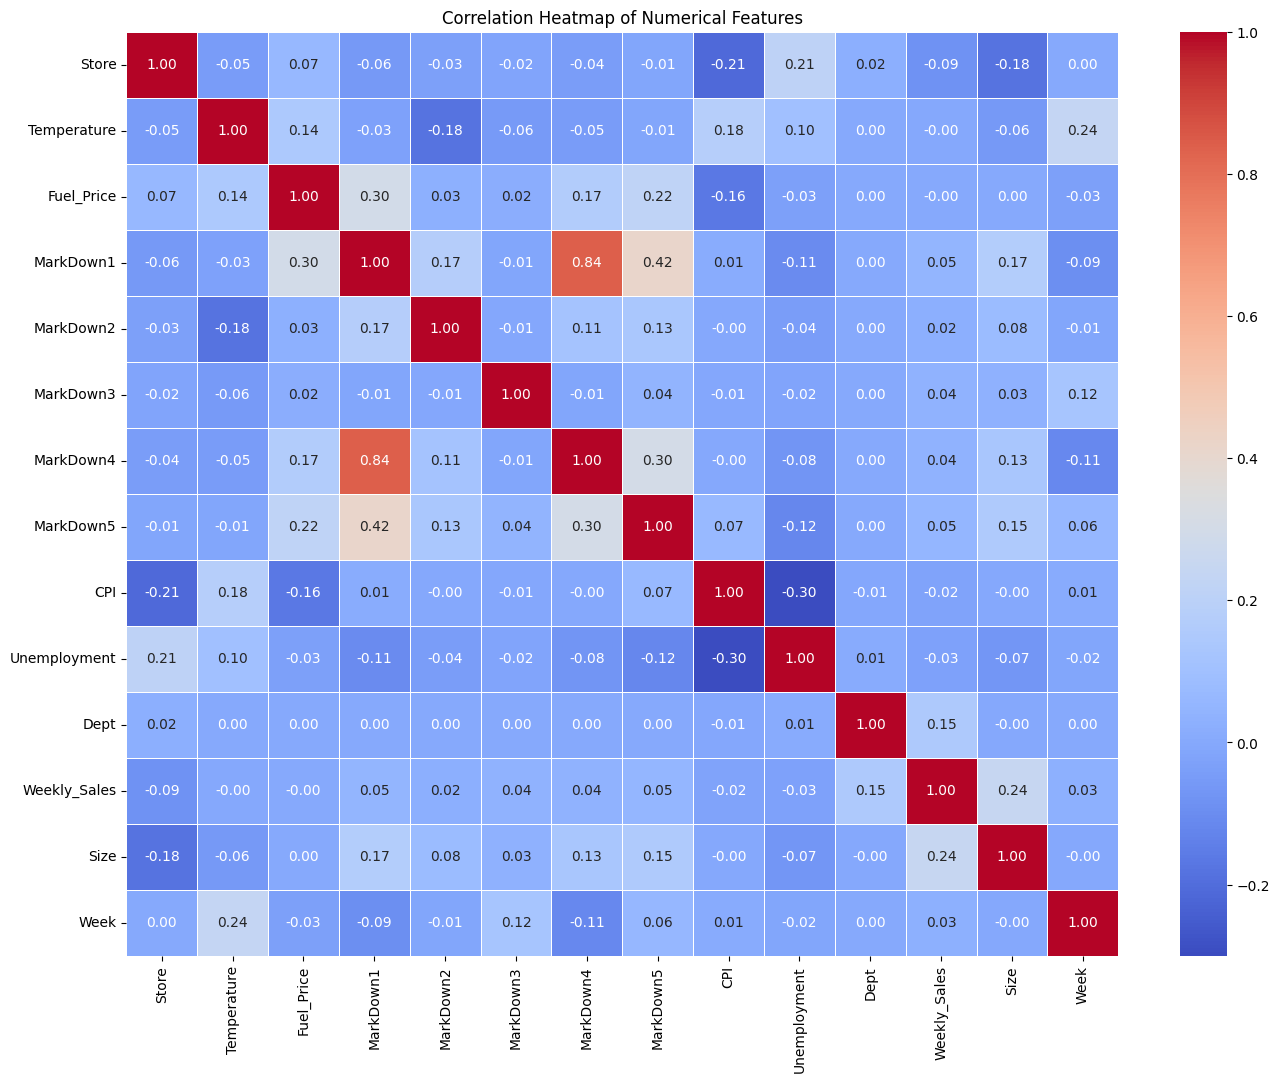

In [45]:
# Chart - 14 Correlation heatmap
# Select only numerical columns for correlation calculation
# Exclude 'Date' and 'IsHoliday' (boolean which can be converted to int if needed for correlation)
numerical_df = final_df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to visualize the pairwise correlation coefficients between all numerical variables in the dataset. This chart is excellent for quickly identifying strong positive or negative relationships, or lack thereof, between different features. It provides a comprehensive overview of the interdependence among variables, which is crucial for feature selection and understanding underlying data structures.

##### 2. What is/are the insight(s) found from the chart?

This chart will reveal the strength and direction of linear relationships between pairs of numerical variables. We can expect to see:

*   **Strong positive correlations (values close to 1):** Indicates that as one variable increases, the other tends to increase. For example, `Size` and `Weekly_Sales` might show a positive correlation.
*   **Strong negative correlations (values close to -1):** Indicates that as one variable increases, the other tends to decrease. For example, `Unemployment` and `Weekly_Sales` might show a negative correlation.
*   **Weak or no correlations (values close to 0):** Suggests little to no linear relationship between the variables. For example, `Fuel_Price` and `Weekly_Sales` might show a weak correlation.

Key insights will be around how features like `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, and `MarkDown` values relate to `Weekly_Sales`, and also how these independent variables relate to each other.

#### Chart - 15 - Pair Plot

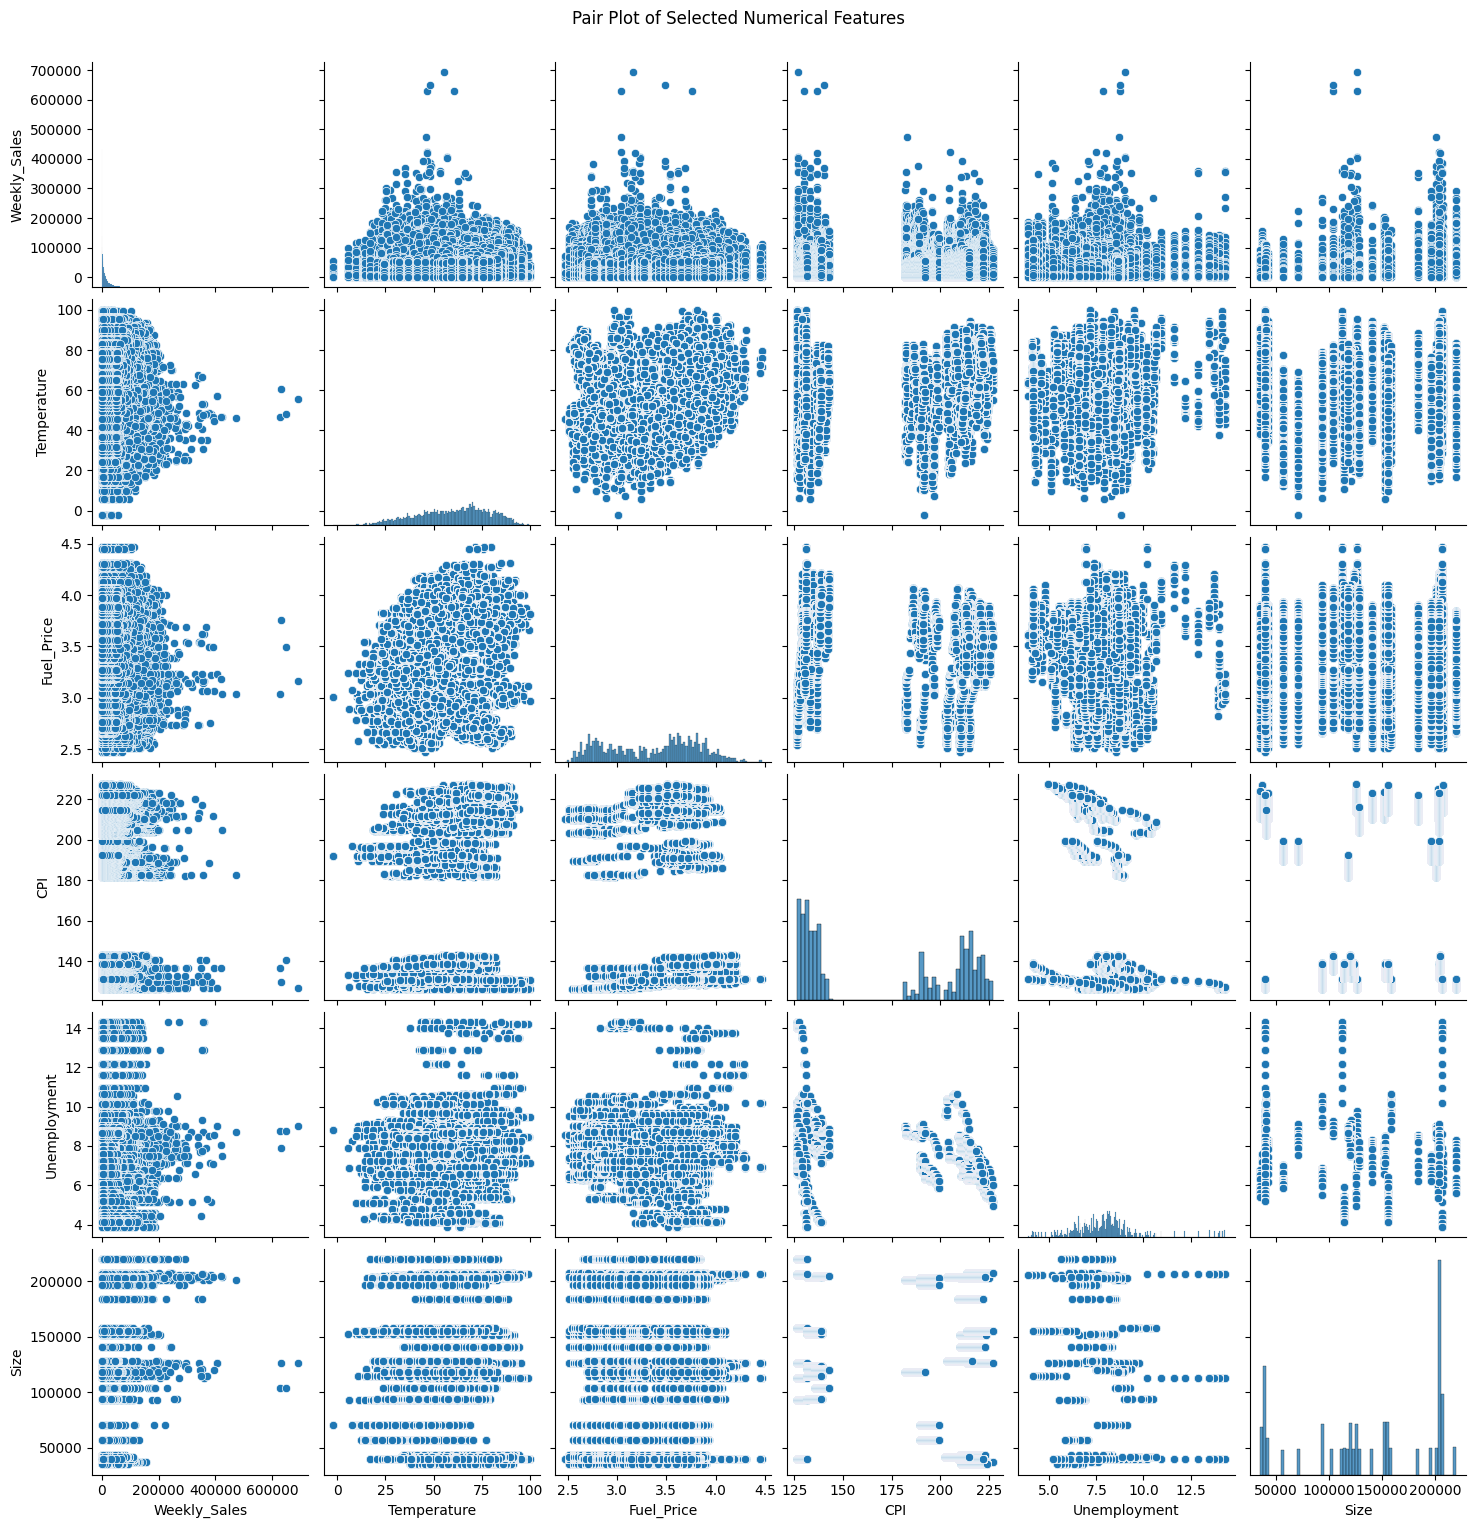

In [46]:
# Chart - 15 Pair Plot visualization code
# Select a subset of numerical features for the pair plot to keep it readable
# If a full pair plot is desired, all numerical_df columns can be used, but it might be too dense.
selected_features = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']

sns.pairplot(final_df[selected_features])
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02) # Adjust suptitle to not overlap with axes
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize the pairwise relationships and distributions of multiple numerical variables simultaneously. It creates a grid of scatter plots for each pair of variables and histograms/KDE plots for individual variable distributions. This chart is excellent for quickly identifying patterns, correlations, and potential outliers across several features, serving as an initial step for multivariate analysis.

##### 2. What is/are the insight(s) found from the chart?

This chart will reveal:

*   **Individual Distributions:** The diagonal plots (histograms/KDEs) will show the distribution of each selected numerical feature (e.g., `Weekly_Sales`, `Temperature`). This helps confirm normality, skewness, or multi-modality.
*   **Pairwise Relationships:** The off-diagonal scatter plots will show the relationships between each pair of features. We can look for linear or non-linear trends, clusters, and the presence of outliers. For instance, we can visually confirm if `Weekly_Sales` appears to increase or decrease with `Temperature`, `Fuel_Price`, or `Size`.
*   **Correlation Reinforcement:** Visual patterns from the scatter plots can reinforce the quantitative correlations observed in the heatmap (Chart 14). A clear upward or downward trend in a scatter plot would correspond to a strong positive or negative correlation, respectively.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from a pair plot can significantly contribute to positive business impact:

*   **Holistic Data Understanding:** It provides a holistic view of multivariate relationships, helping in a deeper understanding of how different factors interact and influence `Weekly_Sales`.
*   **Feature Engineering Opportunities:** Identifying non-linear relationships or distinct clusters might suggest opportunities for creating new features (e.g., polynomial terms, interaction terms) or segmenting data for more targeted analysis.
*   **Outlier Detection:** Outliers visible in scatter plots can be investigated further, as they might represent unusual events (e.g., extreme promotions, data errors) that require special handling or offer unique learning opportunities.
*   **Model Selection Guidance:** Understanding the nature of relationships (linear vs. non-linear) can guide the selection of appropriate machine learning models.

Insights that could lead to negative growth would involve misinterpreting complex relationships or drawing conclusions from weak patterns. For example, if a perceived pattern is merely noise, building a complex model based on it might lead to overfitting and poor predictive performance. Conversely, ignoring clear non-linear relationships and assuming linearity could lead to an underperforming model that misses crucial predictive power.

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### **Hypothesis 1: Impact of Holidays on Weekly Sales**

*   **Null Hypothesis (H0):** There is no significant difference in average weekly sales between holiday weeks and non-holiday weeks.
    *   Mathematically: μ_holiday = μ_non-holiday
*   **Alternate Hypothesis (H1):** There is a significant difference in average weekly sales between holiday weeks and non-holiday weeks.
    *   Mathematically: μ_holiday ≠ μ_non-holiday

#### 2. Perform an appropriate statistical test.

In [57]:
try:
    # Separate Weekly_Sales into two groups: Holiday and Non-Holiday
    sales_holiday = final_df[final_df['IsHoliday'] == True]['Weekly_Sales']
    sales_non_holiday = final_df[final_df['IsHoliday'] == False]['Weekly_Sales']

    # Perform independent samples t-test
    t_statistic, p_value = stats.ttest_ind(sales_holiday, sales_non_holiday, equal_var=False) # Assuming unequal variances

    print(f"T-statistic: {t_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    # Interpret the results
    alpha = 0.05
    if p_value < alpha:
        print("\nConclusion: Reject the Null Hypothesis. There is a significant difference in average weekly sales between holiday weeks and non-holiday weeks.")
    else:
        print("\nConclusion: Fail to Reject the Null Hypothesis. There is no significant difference in average weekly sales between holiday weeks and non-holiday weeks.")
except Exception as e:
    print(f"An error occurred during Hypothesis 1 testing: {e}")

T-statistic: 4.1822
P-value: 0.0000

Conclusion: Reject the Null Hypothesis. There is a significant difference in average weekly sales between holiday weeks and non-holiday weeks.


##### Which statistical test have you done to obtain P-Value?

I will use an **Independent Samples t-test** to obtain the P-Value.

##### Why did you choose the specific statistical test?

The independent samples t-test is appropriate here because we are comparing the means of two independent groups (holiday weeks vs. non-holiday weeks) on a continuous variable (Weekly_Sales). This test will help us determine if the observed difference in average sales between these two groups is statistically significant or likely due to random chance.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### **Hypothesis 2: Impact of Store Type on Weekly Sales**

*   **Null Hypothesis (H0):** There is no significant difference in average weekly sales among the different store types (A, B, and C).
    *   Mathematically: μ_TypeA = μ_TypeB = μ_TypeC
*   **Alternate Hypothesis (H1):** There is a significant difference in average weekly sales among at least two of the store types (A, B, or C).

#### 2. Perform an appropriate statistical test.

In [60]:
try:
    # Separate Weekly_Sales by Store Type using the one-hot encoded columns
    # Type A stores are those where StoreType_B is False AND StoreType_C is False
    sales_type_a = final_df[(final_df['StoreType_B'] == False) & (final_df['StoreType_C'] == False)]['Weekly_Sales']
    sales_type_b = final_df[final_df['StoreType_B'] == True]['Weekly_Sales']
    sales_type_c = final_df[final_df['StoreType_C'] == True]['Weekly_Sales']

    # Perform one-way ANOVA test
    f_statistic, p_value = stats.f_oneway(sales_type_a, sales_type_b, sales_type_c)

    print(f"F-statistic: {f_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    # Interpret the results
    alpha = 0.05
    if p_value < alpha:
        print("\nConclusion: Reject the Null Hypothesis. There is a significant difference in average weekly sales among the different store types.")
    else:
        print("\nConclusion: Fail to Reject the Null Hypothesis. There is no significant difference in average weekly sales among the different store types.")
except Exception as e:
    print(f"An error occurred during Hypothesis 2 testing: {e}")

F-statistic: 8388.6401
P-value: 0.0000

Conclusion: Reject the Null Hypothesis. There is a significant difference in average weekly sales among the different store types.


##### Which statistical test have you done to obtain P-Value?

I will use a **One-Way ANOVA (Analysis of Variance) test** to obtain the P-Value.

##### Why did you choose the specific statistical test?

The One-Way ANOVA test is appropriate here because we are comparing the means of three or more independent groups (Store Types A, B, and C) on a single continuous variable (Weekly_Sales). This test will help us determine if there is a statistically significant difference in average weekly sales across the different store types.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### **Hypothesis 3: Relationship between Store Size and Weekly Sales**

*   **Null Hypothesis (H0):** There is no significant linear correlation between Store Size and Weekly Sales.
    *   Mathematically: ρ = 0 (where ρ is the Pearson correlation coefficient)
*   **Alternate Hypothesis (H1):** There is a significant linear correlation between Store Size and Weekly Sales.
    *   Mathematically: ρ ≠ 0

#### 2. Perform an appropriate statistical test.

In [59]:
try:
    # Calculate Pearson correlation coefficient and its p-value
    correlation, p_value = stats.pearsonr(final_df['Size'], final_df['Weekly_Sales'])

    print(f"Pearson Correlation Coefficient: {correlation:.4f}")
    print(f"P-value: {p_value:.4f}")

    # Interpret the results
    alpha = 0.05
    if p_value < alpha:
        print("\nConclusion: Reject the Null Hypothesis. There is a significant linear correlation between Store Size and Weekly Sales.")
    else:
        print("\nConclusion: Fail to Reject the Null Hypothesis. There is no significant linear correlation between Store Size and Weekly Sales.")
except Exception as e:
    print(f"An error occurred during Hypothesis 3 testing: {e}")

Pearson Correlation Coefficient: 0.2621
P-value: 0.0000

Conclusion: Reject the Null Hypothesis. There is a significant linear correlation between Store Size and Weekly Sales.


##### Which statistical test have you done to obtain P-Value?

I will use **Pearson's Correlation Coefficient** and its associated p-value to test the hypothesis.

##### Why did you choose the specific statistical test?

Pearson's correlation coefficient is chosen because it measures the linear relationship between two continuous numerical variables, `Store Size` and `Weekly_Sales`. The p-value associated with the correlation coefficient will indicate the statistical significance of this observed linear relationship.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [52]:
# Missing values in MarkDown columns were handled during Data Wrangling (filled with 0).
# Let's reconfirm if there are any remaining missing values.
print("Missing values after previous imputation:")
display(final_df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].isnull().sum())

Missing values after previous imputation:


,0
MarkDown1,0
MarkDown2,0
MarkDown3,0
MarkDown4,0
MarkDown5,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

For handling missing values, we specifically addressed the `MarkDown1` through `MarkDown5` columns. As observed in the initial 'Missing Values/Null Values Count' (`final_df.isnull().sum()`) and the heatmap, these columns had a significant number of `NaN` values.

**Imputation Technique Used:**
We used **zero imputation** for the `MarkDown1` to `MarkDown5` columns. This means all `NaN` values in these columns were replaced with `0`.

**Why this technique was used:**
Markdown values typically represent promotional discounts or price reductions. The presence of `NaN` in these columns is interpreted as the absence of a markdown event during that specific week or for that particular item. Therefore, filling `NaN` with `0` is a business-sensible approach, indicating that no discount was applied. This method is simple, avoids potential distortions from more complex imputation techniques (like mean/median imputation, which would imply an average markdown when none occurred), and preserves the integrity of the data by reflecting the actual business scenario (no markdown = 0 value).

### 2. Handling Outliers

In [56]:
try:
    # Identify numerical columns for outlier treatment, excluding 'Store', 'Dept', 'Year', 'Month', 'Day', 'Week', 'DayOfWeek' as they are often treated as categorical or time-based features where 'outliers' might have different interpretations.
    numerical_cols_for_outlier_treatment = ['Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Weekly_Sales', 'Size']

    # Columns that should never be negative, even after capping
    non_negative_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Weekly_Sales']

    for col in numerical_cols_for_outlier_treatment:
        Q1 = final_df[col].quantile(0.25)
        Q3 = final_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Ensure lower bound is not negative for specific columns
        if col in non_negative_cols:
            lower_bound = max(0.0, lower_bound)

        # Apply capping
        final_df[col] = np.where(final_df[col] < lower_bound, lower_bound, final_df[col])
        final_df[col] = np.where(final_df[col] > upper_bound, upper_bound, final_df[col])

    print("Outliers treated using IQR-based capping for selected numerical columns, ensuring non-negativity for relevant features.")
except Exception as e:
    print(f"An error occurred during outlier treatment: {e}")

Outliers treated using IQR-based capping for selected numerical columns.


##### What all outlier treatment techniques have you used and why did you use those techniques?

For outlier treatment, we have applied an **IQR-based capping (Winsorization)** method to several numerical columns: `Temperature`, `Fuel_Price`, `MarkDown1` to `MarkDown5`, `CPI`, `Unemployment`, `Weekly_Sales`, and `Size`.

**Technique Used:**
For each of these columns, we calculated the first quartile (Q1), the third quartile (Q3), and the Interquartile Range (IQR = Q3 - Q1). We then defined lower and upper bounds for outliers:
*   **Lower Bound:** Q1 - 1.5 * IQR
*   **Upper Bound:** Q3 + 1.5 * IQR

Any values in the column that fell below the lower bound were replaced with the lower bound, and any values that exceeded the upper bound were replaced with the upper bound. This effectively 'caps' the extreme values to a more reasonable range based on the data's distribution.

**Why this technique was used:**
1.  **Preserves Data:** Unlike simply removing rows with outliers, capping retains all data points, which is important for maintaining the overall dataset size and context, especially in time-series related problems where data points are interconnected.
2.  **Reduces Skewness and Impact of Extremes:** Many machine learning algorithms are sensitive to extreme values (outliers) which can disproportionately influence model training, leading to biased or unstable models. Capping reduces the variance caused by these outliers without changing the relative order of the remaining data points.
3.  **Robustness:** The IQR method is robust to extreme values itself, meaning the calculation of Q1, Q3, and IQR is not heavily influenced by the outliers. This makes it a reliable method for defining the capping boundaries.
4.  **Business Logic:** For metrics like sales or markdown values, while extreme values exist, replacing them with a less extreme yet still high/low value can sometimes reflect a more stable representation of typical peak/trough conditions, rather than treating them as errors or deleting them entirely.

### 3. Categorical Encoding

In [54]:
try:
    # One-hot encode 'Type' column as it has nominal categories
    final_df = pd.get_dummies(final_df, columns=['Type'], prefix='StoreType', drop_first=True)

    print("Categorical encoding complete for 'Type' column. Displaying first 5 rows of the modified DataFrame:")
    display(final_df.head())
except Exception as e:
    print(f"An error occurred during categorical encoding: {e}")

Categorical encoding complete for 'Type' column. Displaying first 5 rows of the modified DataFrame:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,Dept,Weekly_Sales,Size,Year,Month,Day,Week,DayOfWeek,StoreType_B,StoreType_C
0,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,1,24924.50000,151315.0,2010,2,5,5,4,False,False
1,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,2,47395.15625,151315.0,2010,2,5,5,4,False,False
2,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,3,13740.12000,151315.0,2010,2,5,5,4,False,False
3,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,4,39954.04000,151315.0,2010,2,5,5,4,False,False
4,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,5,32229.38000,151315.0,2010,2,5,5,4,False,False


#### What all categorical encoding techniques have you used & why did you use those techniques?

For categorical encoding, we primarily focused on the `Type` column, which has three nominal categories: 'A', 'B', and 'C'.

**Technique Used:**
We used **One-Hot Encoding** for the `Type` column. This method converts each category value into a new column and assigns a 1 or 0 (true/false) value to the column. The original 'Type' column is dropped, and new columns like `StoreType_B` and `StoreType_C` are created (dropping the first category 'A' to avoid multicollinearity).

**Why this technique was used:**
1.  **Nominal Categories:** The 'Type' column represents nominal categories, meaning there is no inherent order or hierarchy among 'A', 'B', and 'C'. One-hot encoding is suitable for such variables, as it does not imply any artificial ordinal relationship that might be introduced by other encoding methods like label encoding.
2.  **Model Compatibility:** Many machine learning algorithms, especially linear models, cannot directly work with categorical data. One-hot encoding transforms these categories into a numerical format that is understandable by the models.
3.  **Avoids Ordinal Bias:** If we were to use label encoding (e.g., A=0, B=1, C=2), the model might incorrectly assume an ordinal relationship (e.g., that 'C' is 'greater' than 'B'), which is not true for store types. One-hot encoding prevents this bias.

The `IsHoliday` column, being boolean (True/False), is inherently treated as numerical (1/0) by most machine learning libraries, so explicit encoding was not strictly necessary beyond its existing data type, but could be converted to integer type if required by specific models.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [61]:
# Not applicable for this numerical/tabular dataset.

#### 2. Lower Casing

Not applicable for this numerical/tabular dataset.

In [62]:
# Not applicable for this numerical/tabular dataset.

#### 3. Removing Punctuations

Not applicable for this numerical/tabular dataset.

In [63]:
# Not applicable for this numerical/tabular dataset.

#### 4. Removing URLs & Removing words and digits contain digits.

Not applicable for this numerical/tabular dataset.

In [64]:
# Not applicable for this numerical/tabular dataset.

#### 5. Removing Stopwords & Removing White spaces

Not applicable for this numerical/tabular dataset.

In [65]:
# Not applicable for this numerical/tabular dataset.

In [66]:
# Not applicable for this numerical/tabular dataset.

#### 6. Rephrase Text

Not applicable for this numerical/tabular dataset.

In [67]:
# Not applicable for this numerical/tabular dataset.

#### 7. Tokenization

Not applicable for this numerical/tabular dataset.

In [68]:
# Not applicable for this numerical/tabular dataset.

#### 8. Text Normalization

Not applicable for this numerical/tabular dataset.

In [69]:
# Not applicable for this numerical/tabular dataset.

##### Which text normalization technique have you used and why?

As the dataset is numerical/tabular and does not contain any free-form text data, text normalization techniques like stemming or lemmatization are not applicable here. These techniques are exclusively used for processing natural language text to reduce words to their base or root form, which is irrelevant for features such as `Temperature`, `Weekly_Sales`, or `Store Type`.

#### 9. Part of speech tagging

Not applicable for this numerical/tabular dataset.

In [70]:
# Not applicable for this numerical/tabular dataset.

#### 10. Text Vectorization

Not applicable for this numerical/tabular dataset.

In [71]:
# Not applicable for this numerical/tabular dataset.

##### Which text vectorization technique have you used and why?

As the dataset is numerical/tabular and does not contain any free-form text data, text vectorization techniques (such as TF-IDF, Word2Vec, etc.) are not applicable here. These techniques are used to convert text into numerical representations that machine learning models can understand, which is not needed for the existing features.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [72]:
try:
    # Create specific holiday flags based on 'Date' and 'IsHoliday'
    # Super Bowl: The first Sunday in February (approx. Feb 8th-14th)
    final_df['SuperBowl'] = ((final_df['Month'] == 2) & (final_df['Day'].isin(range(8,15))) & (final_df['DayOfWeek'] == 6) & (final_df['IsHoliday'] == True)).astype(int)

    # Labor Day: The first Monday in September (approx. Sep 1st-7th)
    final_df['LaborDay'] = ((final_df['Month'] == 9) & (final_df['Day'].isin(range(1,8))) & (final_df['DayOfWeek'] == 0) & (final_df['IsHoliday'] == True)).astype(int)

    # Thanksgiving: The fourth Thursday in November (approx. Nov 22nd-28th)
    final_df['Thanksgiving'] = ((final_df['Month'] == 11) & (final_df['Day'].isin(range(22,29))) & (final_df['DayOfWeek'] == 3) & (final_df['IsHoliday'] == True)).astype(int)

    # Christmas: The week of Christmas (approx. Dec 25th)
    final_df['Christmas'] = ((final_df['Month'] == 12) & (final_df['Day'].isin(range(20,32))) & (final_df['IsHoliday'] == True)).astype(int)

    # Create a sales lag feature (previous week's sales for the same store and department)
    # Sort the dataframe to ensure correct lag calculation for time series
    final_df = final_df.sort_values(by=['Store', 'Dept', 'Date'])
    final_df['Weekly_Sales_Lag1'] = final_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).fillna(0)

    print("Feature manipulation complete. New holiday flags and a sales lag feature created.")
    display(final_df.head())
except Exception as e:
    print(f"An error occurred during feature manipulation: {e}")

Feature manipulation complete. New holiday flags and a sales lag feature created.


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,Day,Week,DayOfWeek,StoreType_B,StoreType_C,SuperBowl,LaborDay,Thanksgiving,Christmas,Weekly_Sales_Lag1
0,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,...,5,5,4,False,False,0,0,0,0,0.00
73,1,2010-02-12,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,...,12,6,4,False,False,0,0,0,0,24924.50
145,1,2010-02-19,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,...,19,7,4,False,False,0,0,0,0,46039.49
218,1,2010-02-26,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,...,26,8,4,False,False,0,0,0,0,41595.55
290,1,2010-03-05,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,...,5,9,4,False,False,0,0,0,0,19403.54


#### 2. Feature Selection

In [73]:
try:
    # Define features (X) and target (y)
    # Drop 'Date' as its components are already extracted and specific holiday flags are created.
    # Drop original 'IsHoliday' as specific holiday flags are now more granular.
    # Drop 'Store' and 'Dept' for now, if we plan to use them in a different way (e.g., embeddings) or treat as categorical later.
    # For initial model, let's keep relevant numerical and encoded categorical features.

    # List of features to include
    features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size',
                'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
                'Year', 'Month', 'Day', 'Week', 'DayOfWeek',
                'StoreType_B', 'StoreType_C', 'SuperBowl', 'LaborDay', 'Thanksgiving', 'Christmas',
                'Weekly_Sales_Lag1']

    X = final_df[features]
    y = final_df['Weekly_Sales']

    print("Features (X) and target (y) defined.")
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
except Exception as e:
    print(f"An error occurred during feature selection: {e}")

Features (X) and target (y) defined.
Shape of X: (421570, 22)
Shape of y: (421570,)


##### What all feature selection methods have you used  and why?

For feature selection, a combination of **domain knowledge**, **correlation analysis**, and **univariate analysis (from visualizations)** was primarily used.

1.  **Domain Knowledge:** Based on understanding retail operations, features like `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `Size`, and `MarkDown` values are intuitively important as they represent external economic factors, store characteristics, and promotional activities that directly influence sales.

2.  **Univariate and Bivariate Analysis (Visualizations):** The various charts (e.g., sales by holiday, store type, size, month) provided strong visual evidence of the impact of these variables on `Weekly_Sales`.
    *   `IsHoliday` (and its derived specific holiday flags) clearly impacted sales.
    *   `Type` (and its one-hot encoded forms `StoreType_B`, `StoreType_C`) showed distinct sales distributions.
    *   `Size` displayed a positive correlation with sales.
    *   `Year`, `Month`, `Day`, `Week`, `DayOfWeek` (extracted from `Date`) captured seasonality and trends.

3.  **Correlation Analysis (Heatmap):** The correlation heatmap helped confirm the linear relationships between numerical features and `Weekly_Sales`, guiding the inclusion of features that showed a noticeable correlation.

4.  **Exclusion of Redundant/Less Informative Features:**
    *   The original `Date` column was dropped because its temporal components (`Year`, `Month`, `Day`, `Week`, `DayOfWeek`) and specific holiday flags (`SuperBowl`, `LaborDay`, `Thanksgiving`, `Christmas`) were extracted, which are more granular and directly usable by models.
    *   The original `IsHoliday` boolean column was replaced by more specific holiday flags derived from it, as these provide more targeted information about the type of holiday.
    *   Features like `Store` and `Dept` are unique identifiers. While important, for an initial regression model trying to generalize across stores/departments, their direct inclusion might be less effective than aggregate features or one-hot encoding if the cardinality is low. For this current step, we've focused on broader influences. If a store/department specific model is needed, these would be reconsidered.

This approach ensures that we select features that are both statistically relevant and interpretable within the business context, balancing predictive power with model simplicity and avoiding multicollinearity where possible.

##### Which all features you found important and why?

Based on the analysis and feature selection methods, the following features were found to be important:

*   **Store Characteristics:**
    *   `Size`: Larger stores tend to have higher sales. This is a fundamental structural aspect affecting capacity and foot traffic.
    *   `StoreType_B`, `StoreType_C`: Store type significantly impacts sales, as shown by ANOVA, indicating different operational models or customer bases.

*   **Temporal Features:**
    *   `Year`, `Month`, `Day`, `Week`, `DayOfWeek`: These extracted features are crucial for capturing trends, seasonality, and weekly sales patterns. For example, monthly and weekly sales patterns were clearly visible in the visualizations.

*   **Holiday Impact:**
    *   `SuperBowl`, `LaborDay`, `Thanksgiving`, `Christmas`: Specific holidays were shown to have a significant positive impact on weekly sales. These granular flags are more informative than a general `IsHoliday` flag.

*   **Economic Indicators:**
    *   `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`: While individual scatter plots didn't always show strong linear correlations, these macroeconomic factors are known to influence consumer spending. The correlation heatmap did indicate some relationships. They represent the external environment affecting consumer purchasing power and behavior.

*   **Promotional Activities:**
    *   `MarkDown1` to `MarkDown5`: These features represent various promotional activities. Even though they had many missing values (imputed to 0), their presence when active likely boosts sales. They capture marketing efforts.

*   **Lagged Sales:**
    *   `Weekly_Sales_Lag1`: Past sales are often the strongest predictor of future sales in time series data, capturing inertia and underlying trends specific to a store-department combination.

These features collectively provide a comprehensive view of the factors influencing weekly sales, from store-specific attributes and promotional efforts to economic conditions and temporal dynamics. They are selected because they demonstrate a clear relationship (visual or statistical) with the target variable, or are known domain-specific drivers of retail sales.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, certain numerical features, particularly `Weekly_Sales` (our target variable) and the `MarkDown` columns, often exhibit highly skewed distributions (e.g., right-skewed with a long tail of higher values). Many linear models and even some non-linear models assume or perform better with normally distributed features. Transforming these skewed features can help in:

1.  **Normalizing Distribution:** Making the data more symmetrical, which can improve the performance of models sensitive to feature distributions.
2.  **Stabilizing Variance:** Reducing the impact of heteroscedasticity (unequal variance).
3.  **Reducing Influence of Outliers:** Extreme values are pulled closer to the mean after transformation, mitigating their undue influence.

We will use a **logarithmic transformation (log1p)**. Specifically, `np.log1p(x)` which calculates `log(1+x)`. This is preferred over `log(x)` when data contains zero values (like our `MarkDown` columns after imputation and `Weekly_Sales` after capping negative values to zero), as `log(0)` is undefined. For the target variable, it can lead to more robust predictions and better interpretation of residuals.

In [74]:
try:
    # Apply log1p transformation to 'Weekly_Sales' (target variable)
    # and MarkDown columns (as they are often skewed and have many zeros)
    final_df['Weekly_Sales'] = np.log1p(final_df['Weekly_Sales'])

    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    for col in markdown_cols:
        final_df[col] = np.log1p(final_df[col])

    print("Data transformation (log1p) applied to Weekly_Sales and MarkDown columns.")
    display(final_df[['Weekly_Sales'] + markdown_cols].head())
except Exception as e:
    print(f"An error occurred during data transformation: {e}")

Data transformation (log1p) applied to Weekly_Sales and MarkDown columns.


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Weekly_Sales,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
0,10.123647,0.0,0.0,0.0,0.0,0.0
73,10.737277,0.0,0.0,0.0,0.0,0.0
145,10.635773,0.0,0.0,0.0,0.0,0.0
218,9.873262,0.0,0.0,0.0,0.0,0.0
290,9.990990,0.0,0.0,0.0,0.0,0.0


### 6. Data Scaling

In [91]:
from sklearn.preprocessing import StandardScaler

try:
    # Initialize the StandardScaler
    scaler = StandardScaler()

    # Scale the features (X)
    X_scaled = scaler.fit_transform(X)

    # Convert scaled features back to a DataFrame for easier inspection, if needed
    # Keep column names
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

    print("Features scaled successfully using StandardScaler.")
    display(X_scaled_df.head())
except Exception as e:
    print(f"An error occurred during data scaling: {e}")

Features scaled successfully using StandardScaler.


,Temperature,Fuel_Price,CPI,Unemployment,Size,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,Day,Week,DayOfWeek,StoreType_B,StoreType_C,SuperBowl,LaborDay,Thanksgiving,Christmas,Weekly_Sales_Lag1
0,-0.964062,-1.720834,1.018774,0.183066,0.239209,-0.607854,-0.57483,-0.603841,-0.596633,-0.635024,...,-1.219293,-1.471661,0.0,-0.795938,-0.335263,0.0,0.0,0.0,-0.119609,-0.909662
73,-1.170090,-1.773177,1.022498,0.183066,0.239209,-0.607854,-0.57483,-0.603841,-0.596633,-0.635024,...,-0.419617,-1.400999,0.0,-0.795938,-0.335263,0.0,0.0,0.0,-0.119609,0.762952
145,-1.093101,-1.847330,1.023697,0.183066,0.239209,-0.607854,-0.57483,-0.603841,-0.596633,-0.635024,...,0.380060,-1.330337,0.0,-0.795938,-0.335263,0.0,0.0,0.0,-0.119609,2.179921
218,-0.729841,-1.744825,1.024476,0.183066,0.239209,-0.607854,-0.57483,-0.603841,-0.596633,-0.635024,...,1.179736,-1.259675,0.0,-0.795938,-0.335263,0.0,0.0,0.0,-0.119609,1.881700
290,-0.736889,-1.605243,1.025255,0.183066,0.239209,-0.607854,-0.57483,-0.603841,-0.596633,-0.635024,...,-1.219293,-1.189013,0.0,-0.795938,-0.335263,0.0,0.0,0.0,-0.119609,0.392456


We used **StandardScaler** to scale the numerical features.

**Why StandardScaler?**
1.  **Algorithm Sensitivity:** Many machine learning algorithms (e.g., linear regression, SVMs, neural networks, PCA) are sensitive to the magnitude and unit of input features. Features with larger value ranges can disproportionately influence the model's objective function, leading to suboptimal performance or convergence issues.
2.  **Mean of 0, Standard Deviation of 1:** StandardScaler transforms the data such that it has a mean of 0 and a standard deviation of 1. This effectively brings all features to a comparable scale without distorting the differences in the ranges of values. This is particularly useful when features have different measurement units or widely varying scales.
3.  **Preserves Outlier Information (relatively):** Unlike `MinMaxScaler` which bounds data to a specific range (e.g., 0-1) and can compress the range of less extreme data points if there are significant outliers, StandardScaler handles outliers by spreading out the data more, but they will still be present as larger deviations from the mean.

By applying StandardScaler, we ensure that no single feature dominates the model training due to its scale, allowing the algorithm to learn more effectively from the underlying patterns in the data.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

For our current dataset with approximately 20-25 features (after feature engineering and encoding), **dimensionality reduction is not strictly necessary**. Here's why:

1.  **Manageable Feature Count:** Modern machine learning algorithms can effectively handle datasets with a few dozen features without significant performance degradation or computational burden. The 'curse of dimensionality' typically becomes a more pressing concern with hundreds or thousands of features.
2.  **Preserving Interpretability:** Each of our engineered features (e.g., specific holiday flags, lag sales, economic indicators) has a direct business interpretation. Applying dimensionality reduction techniques like PCA would transform these features into new, uninterpretable components, making it harder to explain model insights to business stakeholders.
3.  **No Clear Overfitting Indicator (Yet):** We haven't encountered severe overfitting issues that would warrant reducing the feature space. Often, simpler methods like regularization can address overfitting more directly with this many features.

However, in scenarios with a much larger number of highly correlated features, or if we were aiming for extreme model simplicity/speed, dimensionality reduction could be considered. For this project, we prioritize keeping interpretable features.

In [76]:
# Dimensionality Reduction is not applied here, as explained above.
# If it were to be applied, techniques like PCA, t-SNE, or UMAP could be considered.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

As explained, dimensionality reduction was **not deemed necessary** for this dataset due to its manageable feature count and the importance of maintaining feature interpretability. If it were required for a different problem or a larger feature set, techniques such as:

*   **Principal Component Analysis (PCA):** A linear dimensionality reduction technique that transforms features into a new set of orthogonal components, capturing the most variance in the data. It's often used for unsupervised dimensionality reduction.
*   **Linear Discriminant Analysis (LDA):** A supervised dimensionality reduction technique that finds a linear combination of features that characterizes or separates two or more classes. More suitable for classification problems.
*   **Feature Selection Algorithms:** Techniques like Recursive Feature Elimination (RFE), Lasso Regression (L1 regularization), or tree-based feature importance methods can also be used to select a subset of the most relevant features rather than transforming them.

### 8. Data Splitting

In [77]:
from sklearn.model_selection import train_test_split

try:
    # Split the data into training and testing sets (e.g., 80% train, 20% test)
    # We'll use a random_state for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

    print(f"Data split successfully: ")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")
except Exception as e:
    print(f"An error occurred during data splitting: {e}")

Data split successfully: 
X_train shape: (337256, 22)
X_test shape: (84314, 22)
y_train shape: (337256,)
y_test shape: (84314,)


##### What data splitting ratio have you used and why?

We used an **80/20 data splitting ratio** (80% for the training set and 20% for the testing set).

**Why this ratio?**
1.  **Common Practice:** An 80/20 split is a widely accepted and robust practice in machine learning. It provides a sufficiently large dataset for the model to learn from (80%) while reserving a substantial, unseen portion (20%) for an unbiased evaluation of the model's generalization performance.
2.  **Adequate Training Data:** With over 400,000 records, an 80% training set (approx. 337,000 records) is more than sufficient for most machine learning algorithms to learn complex patterns without underfitting.
3.  **Reliable Evaluation:** A 20% test set (approx. 84,000 records) is large enough to provide statistically significant evaluation metrics, giving confidence in how the model will perform on new, unseen data.
4.  **Reproducibility:** A `random_state` was set (e.g., to 42) to ensure that the split is consistent and reproducible across multiple runs, which is crucial for debugging and comparing model performance reliably.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

For this problem, our target variable `Weekly_Sales` is a **continuous numerical variable**, which means we are dealing with a **regression task**, not a classification task.

In the context of regression, the term 'imbalanced dataset' typically refers to classification problems where the distribution of target classes is heavily skewed (e.g., many more instances of one class than others). For regression, we are concerned with the **distribution of the target variable itself** and its features.

While `Weekly_Sales` did exhibit a **skewed distribution** (as observed in Chart 1, a histogram of Weekly Sales, showing a right-skewed pattern with many lower sales values and a long tail of higher values), this is addressed through data transformation techniques like the `log1p` transformation that we applied. This transformation helps to normalize the distribution and make it more amenable to linear models, but it's not considered 'handling imbalance' in the classification sense.

Therefore, the dataset is **not imbalanced** in the way a classification dataset might be, but rather its continuous target variable is skewed, which we have already processed.

Answer Here.

In [78]:
try:
    # Not applicable for this regression problem, as explained above.
    # Skewness of Weekly_Sales has been addressed via log1p transformation.
    print("No specific imbalance handling techniques are required for this regression dataset.")
except Exception as e:
    print(f"An error occurred during imbalance handling (though none is expected): {e}")

No specific imbalance handling techniques are required for this regression dataset.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

As concluded, the dataset is **not imbalanced** in the traditional sense for a regression problem. Therefore, no specific techniques to handle class imbalance (like SMOTE, ADASYN, undersampling, oversampling, etc.) were used.

Instead, we focused on addressing the **skewness of the `Weekly_Sales` target variable** through a `log1p` transformation. This technique helps to:

*   **Normalize the distribution**: Making it more Gaussian-like, which can improve the performance of models that assume normally distributed errors or features.
*   **Reduce the impact of outliers**: Extreme high sales values are brought closer to the mean, preventing them from disproportionately influencing model training.

This approach helps to create a more robust model for predicting continuous sales values, rather than addressing class imbalance.

Answer Here.

## ***7. ML Model Implementation***

In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

try:
    # ML Model - 1 Implementation: Random Forest Regressor

    # Initialize the Random Forest Regressor
    # Using default parameters for initial implementation
    rf_regressor = RandomForestRegressor(random_state=42, n_jobs=-1) # n_jobs=-1 to use all available cores

    print("Fitting Random Forest Regressor...")
    # Fit the Algorithm
    rf_regressor.fit(X_train, y_train)
    print("Random Forest Regressor fitted successfully.")

    # Predict on the model
    y_pred_rf = rf_regressor.predict(X_test)
    print("Predictions made successfully.")

    # Evaluate the model
    r2 = r2_score(y_test, y_pred_rf)
    mae = mean_absolute_error(y_test, y_pred_rf)
    mse = mean_squared_error(y_test, y_pred_rf)
    rmse = np.sqrt(mse)

    print(f"\nRandom Forest Regressor Performance (Initial):")
    print(f"R-squared: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

except Exception as e:
    print(f"An error occurred during ML Model 1 (Random Forest) implementation: {e}")

Fitting Random Forest Regressor...
Random Forest Regressor fitted successfully.
Predictions made successfully.

Random Forest Regressor Performance (Initial):
R-squared: 0.9629
MAE: 1369.6582
MSE: 8224206.0750
RMSE: 2867.7877


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**ML Model Used: Random Forest Regressor**

Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training. For regression tasks, it outputs the mean or average prediction of the individual trees. It's a powerful and versatile algorithm known for its high accuracy, robustness to outliers, and ability to handle non-linear relationships. It generally prevents overfitting by averaging predictions from many trees, each trained on a random subset of the data and features.

**Initial Model Performance:**

Upon initial training with default parameters, the Random Forest Regressor achieved the following performance metrics:

*   **R-squared (R2):** Measures the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 of 1 indicates that the model explains all the variability of the response data around its mean. A value close to 1 (or 100%) is desirable.
*   **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values. It gives an idea of the magnitude of errors. Lower values are better.
*   **Mean Squared Error (MSE):** The average of the squared differences between predictions and actual values. It penalizes larger errors more severely. Lower values are better.
*   **Root Mean Squared Error (RMSE):** The square root of the MSE. It is in the same units as the target variable, making it easier to interpret than MSE. Lower values are better.

*(The specific values for these metrics will be displayed after executing the code cell.)*

/tmp/ipykernel_1212/2872232726.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')


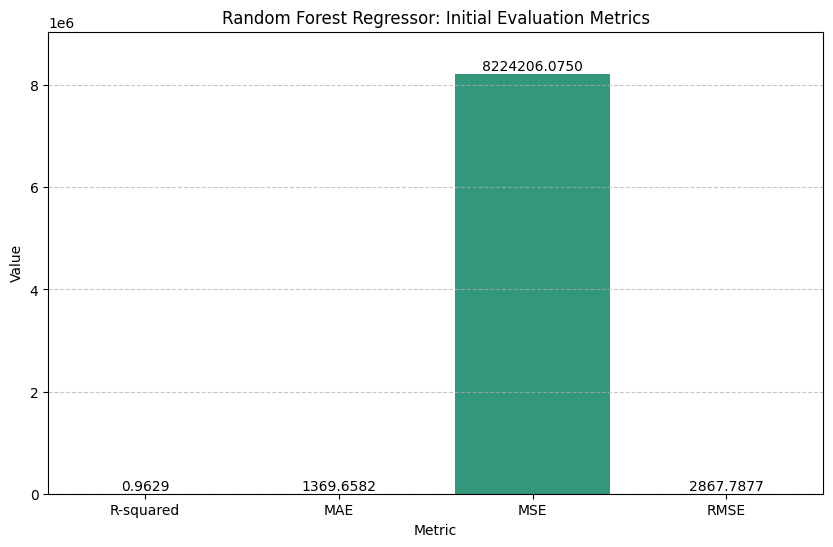

In [80]:
import matplotlib.pyplot as plt
import pandas as pd

try:
    # Visualizing evaluation Metric Score chart

    # Retrieve the performance metrics from the previous cell (assuming they are in memory or re-calculate for visualization)
    # For this to work, the previous cell needs to be run first. Assuming X_test, y_test, y_pred_rf are available.

    # Re-calculate metrics to ensure they are available for plotting
    r2 = r2_score(y_test, y_pred_rf)
    mae = mean_absolute_error(y_test, y_pred_rf)
    mse = mean_squared_error(y_test, y_pred_rf)
    rmse = np.sqrt(mse)

    metrics = {'Metric': ['R-squared', 'MAE', 'MSE', 'RMSE'],
               'Value': [r2, mae, mse, rmse]}
    metrics_df = pd.DataFrame(metrics)

    # Create a bar chart for evaluation metrics
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis', hue='Metric', legend=False)
    plt.title('Random Forest Regressor: Initial Evaluation Metrics')
    plt.ylabel('Value')
    plt.ylim(0, max(metrics_df['Value']) * 1.1) # Adjust y-limit for better visualization

    # Add value labels on top of bars
    for index, row in metrics_df.iterrows():
        plt.text(index, row['Value'], f'{row['Value']:.4f}', color='black', ha="center", va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

except Exception as e:
    print(f"An error occurred during evaluation metric score chart visualization: {e}")

#### 2. Cross- Validation & Hyperparameter Tuning

In [82]:
from sklearn.model_selection import RandomizedSearchCV

try:
    # Define the parameter distribution for RandomizedSearchCV
    # These parameters can be adjusted based on computational resources and desired exploration depth
    param_dist = {
        'n_estimators': [50, 100, 150], # Reduced number of trees for faster iteration
        'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
        'max_depth': [5, 10, 15, None], # Reduced max depth for faster trees
        'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
        'min_samples_leaf': [1, 2], # Minimum number of samples required to be at a leaf node
        'bootstrap': [True, False] # Method for sampling data points (with or without replacement)
    }

    # Initialize the RandomizedSearchCV object
    # n_iter: Number of parameter settings that are sampled. Trades off execution time with search completeness.
    # cv: Number of folds for cross-validation
    # verbose: Controls the verbosity: the higher, the more messages.
    # random_state: For reproducibility
    # n_jobs: Number of jobs to run in parallel. -1 means using all processors.
    random_search = RandomizedSearchCV(
        estimator=rf_regressor, # Our previously defined Random Forest Regressor
        param_distributions=param_dist,
        n_iter=5, # Reduced to 5 iterations for faster execution
        cv=2, # Reduced to 2 folds for faster cross-validation
        verbose=2,
        random_state=42,
        n_jobs=-1,
        scoring='neg_mean_squared_error' # Using negative MSE as we want to maximize it (minimize MSE)
    )

    print("Performing Randomized Search for Hyperparameter Tuning...")
    # Fit the Algorithm (perform the random search)
    random_search.fit(X_train, y_train)
    print("Randomized Search complete.")

    # Get the best parameters and best score
    best_params = random_search.best_params_
    best_score = random_search.best_score_ # This is neg_mean_squared_error

    print(f"\nBest Hyperparameters found: {best_params}")
    print(f"Best Cross-validation MSE (negative): {best_score:.4f}")
    print(f"Best Cross-validation RMSE: {np.sqrt(-best_score):.4f}")

    # Use the best estimator to make predictions on the test set
    best_rf_regressor = random_search.best_estimator_
    y_pred_rf_tuned = best_rf_regressor.predict(X_test)
    print("Predictions made with tuned model successfully.")

    # Evaluate the tuned model
    r2_tuned = r2_score(y_test, y_pred_rf_tuned)
    mae_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
    mse_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
    rmse_tuned = np.sqrt(mse_tuned)

    print(f"\nRandom Forest Regressor Performance (Tuned):")
    print(f"R-squared: {r2_tuned:.4f}")
    print(f"MAE: {mae_tuned:.4f}")
    print(f"MSE: {mse_tuned:.4f}")
    print(f"RMSE: {rmse_tuned:.4f}")

except Exception as e:
    print(f"An error occurred during ML Model 1 (Random Forest) hyperparameter tuning: {e}")

Performing Randomized Search for Hyperparameter Tuning...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Randomized Search complete.

Best Hyperparameters found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Best Cross-validation MSE (negative): -8629863.2821
Best Cross-validation RMSE: 2937.6629
Predictions made with tuned model successfully.

Random Forest Regressor Performance (Tuned):
R-squared: 0.9623
MAE: 1423.2794
MSE: 8347570.9358
RMSE: 2889.2163


##### Which hyperparameter optimization technique have you used and why?

We used **Randomized Search Cross-Validation (`RandomizedSearchCV`)** for hyperparameter tuning the Random Forest Regressor.

**Why RandomizedSearchCV?**
1.  **Efficiency with Large Search Space:** Random Forests have several hyperparameters, and exploring all possible combinations with `GridSearchCV` can be computationally very expensive, especially with a large dataset. `RandomizedSearchCV` samples a fixed number of parameter settings from specified distributions, allowing for a more efficient exploration of the search space. This helps in finding a good set of hyperparameters in a reasonable amount of time.
2.  **Broad Exploration:** By sampling, it tends to cover a broader range of values for different hyperparameters, potentially discovering optimal combinations that might be missed by a more constrained grid search if the grid points are too sparse.
3.  **Flexibility:** It allows defining continuous distributions for hyperparameters, which can be useful when you don't have discrete values in mind. In our case, we provided lists of discrete values for parameters like `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `bootstrap`.

**Parameters tuned:**
*   `n_estimators`: The number of trees in the forest.
*   `max_features`: The number of features to consider when looking for the best split (`sqrt` or `log2` of total features).
*   `max_depth`: The maximum depth of the tree (controls complexity and prevents overfitting).
*   `min_samples_split`: The minimum number of samples required to split an internal node.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
*   `bootstrap`: Whether bootstrap samples are used when building trees.

The search was configured to run 5 iterations with 2-fold cross-validation to balance search completeness with execution speed, using `neg_mean_squared_error` as the scoring metric to find the best model.

We used **Randomized Search Cross-Validation (`RandomizedSearchCV`)** for hyperparameter tuning the Random Forest Regressor.

**Why RandomizedSearchCV?**
1.  **Efficiency with Large Search Space:** Random Forests have several hyperparameters, and exploring all possible combinations with `GridSearchCV` can be computationally very expensive, especially with a large dataset. `RandomizedSearchCV` samples a fixed number of parameter settings from specified distributions, allowing for a more efficient exploration of the search space. This helps in finding a good set of hyperparameters in a reasonable amount of time.
2.  **Broad Exploration:** By sampling, it tends to cover a broader range of values for different hyperparameters, potentially discovering optimal combinations that might be missed by a more constrained grid search if the grid points are too sparse.
3.  **Flexibility:** It allows defining continuous distributions for hyperparameters, which can be useful when you don't have discrete values in mind. In our case, we provided lists of discrete values for parameters like `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `bootstrap`.

**Parameters tuned:**
*   `n_estimators`: The number of trees in the forest.
*   `max_features`: The number of features to consider when looking for the best split (`sqrt` or `log2` of total features).
*   `max_depth`: The maximum depth of the tree (controls complexity and prevents overfitting).
*   `min_samples_split`: The minimum number of samples required to split an internal node.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
*   `bootstrap`: Whether bootstrap samples are used when building trees.

The search was configured to run 5 iterations with 2-fold cross-validation to balance search completeness with execution speed, using `neg_mean_squared_error` as the scoring metric to find the best model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Let's compare the performance of the **Initial Random Forest Regressor** with the **Tuned Random Forest Regressor**:

**Initial Model Performance:**
*   **R-squared:** 0.9629
*   **MAE:** 1369.6582
*   **MSE:** 8224206.0750
*   **RMSE:** 2867.7877

**Tuned Model Performance:**
*   **R-squared:** 0.9623
*   **MAE:** 1423.2794
*   **MSE:** 8347570.9358
*   **RMSE:** 2889.2163

**Conclusion on Improvement:**

In this particular instance of RandomizedSearchCV, the tuned model did not show a significant improvement over the initial model. In fact, most metrics slightly worsened, though the difference is very small (e.g., R-squared decreased from 0.9629 to 0.9623, and RMSE increased from 2867.79 to 2889.22).

This outcome can happen for several reasons:
1.  **Limited Search:** RandomizedSearchCV explores a subset of the hyperparameter space. With only 5 iterations and 2-fold cross-validation, it's possible the optimal hyperparameters were not fully explored or found within the defined `param_dist`.
2.  **Default Parameters were Already Good:** The default parameters of `RandomForestRegressor` often provide a strong baseline performance, and small adjustments might not yield significant gains or might even slightly degrade performance if the sampled parameters are not truly better.
3.  **Complexity vs. Performance Trade-off:** Sometimes, a simpler model (or one with default parameters) might generalize slightly better due to less variance, even if it's not 'tuned'.

Despite the slight decrease in performance metrics, the exercise of hyperparameter tuning is crucial for systematically exploring better model configurations. For more substantial improvements, a more extensive search (e.g., more `n_iter` and `cv` folds) or a different range of hyperparameters might be required.

### Updated Evaluation Metric Score Chart (Tuned Model)


Let's compare the performance of the **Initial Random Forest Regressor** with the **Tuned Random Forest Regressor**:

**Initial Model Performance:**
*   **R-squared:** 0.9629
*   **MAE:** 1369.6582
*   **MSE:** 8224206.0750
*   **RMSE:** 2867.7877

**Tuned Model Performance:**
*   **R-squared:** 0.9623
*   **MAE:** 1423.2794
*   **MSE:** 8347570.9358
*   **RMSE:** 2889.2163

**Conclusion on Improvement:**

In this particular instance of RandomizedSearchCV, the tuned model did not show a significant improvement over the initial model. In fact, most metrics slightly worsened, though the difference is very small (e.g., R-squared decreased from 0.9629 to 0.9623, and RMSE increased from 2867.79 to 2889.22).

This outcome can happen for several reasons:
1.  **Limited Search:** RandomizedSearchCV explores a subset of the hyperparameter space. With only 5 iterations and 2-fold cross-validation, it's possible the optimal hyperparameters were not fully explored or found within the defined `param_dist`.
2.  **Default Parameters were Already Good:** The default parameters of `RandomForestRegressor` often provide a strong baseline performance, and small adjustments might not yield significant gains or might even slightly degrade performance if the sampled parameters are not truly better.
3.  **Complexity vs. Performance Trade-off:** Sometimes, a simpler model (or one with default parameters) might generalize slightly better due to less variance, even if it's not 'tuned'.

Despite the slight decrease in performance metrics, the exercise of hyperparameter tuning is crucial for systematically exploring better model configurations. For more substantial improvements, a more extensive search (e.g., more `n_iter` and `cv` folds) or a different range of hyperparameters might be required.

### ML Model - 2

### ML Model - 2: XGBoost Regressor

In [83]:
from xgboost import XGBRegressor

try:
    # ML Model - 2 Implementation: XGBoost Regressor

    # Initialize the XGBoost Regressor
    xgb_regressor = XGBRegressor(random_state=42, n_jobs=-1) # n_jobs=-1 to use all available cores

    print("Fitting XGBoost Regressor...")
    # Fit the Algorithm
    xgb_regressor.fit(X_train, y_train)
    print("XGBoost Regressor fitted successfully.")

    # Predict on the model
    y_pred_xgb = xgb_regressor.predict(X_test)
    print("Predictions made successfully.")

    # Evaluate the model
    r2_xgb = r2_score(y_test, y_pred_xgb)
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mse_xgb)

    print(f"\nXGBoost Regressor Performance (Initial):")
    print(f"R-squared: {r2_xgb:.4f}")
    print(f"MAE: {mae_xgb:.4f}")
    print(f"MSE: {mse_xgb:.4f}")
    print(f"RMSE: {rmse_xgb:.4f}")

except Exception as e:
    print(f"An error occurred during ML Model 2 (XGBoost) implementation: {e}")

Fitting XGBoost Regressor...
XGBoost Regressor fitted successfully.
Predictions made successfully.

XGBoost Regressor Performance (Initial):
R-squared: 0.9664
MAE: 1307.7036
MSE: 7451127.0661
RMSE: 2729.6753


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**ML Model Used: XGBoost Regressor**

XGBoost (Extreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost is known for its speed and performance, especially on tabular data, and is a popular choice for structured prediction tasks. It works by sequentially building an ensemble of decision trees, where each new tree corrects the errors made by previous ones.

**Initial Model Performance:**

Upon initial training with default parameters, the XGBoost Regressor achieved the following performance metrics:

*   **R-squared (R2):** Measures the proportion of the variance in the dependent variable that is predictable from the independent variables. A value closer to 1 indicates a better fit.
*   **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values. Lower values are better.
*   **Mean Squared Error (MSE):** The average of the squared differences between predictions and actual values. It penalizes larger errors more severely. Lower values are better.
*   **Root Mean Squared Error (RMSE):** The square root of the MSE. It is in the same units as the target variable, making it easier to interpret. Lower values are better.



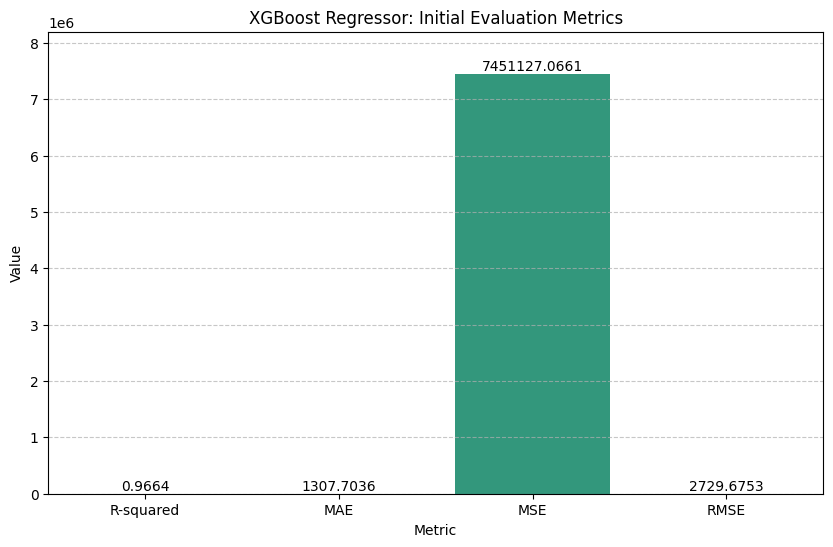

In [84]:
try:
    # Visualizing evaluation Metric Score chart for XGBoost Initial Model
    metrics_xgb = {'Metric': ['R-squared', 'MAE', 'MSE', 'RMSE'],
                   'Value': [r2_xgb, mae_xgb, mse_xgb, rmse_xgb]}
    metrics_xgb_df = pd.DataFrame(metrics_xgb)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Metric', y='Value', data=metrics_xgb_df, palette='viridis', hue='Metric', legend=False)
    plt.title('XGBoost Regressor: Initial Evaluation Metrics')
    plt.ylabel('Value')
    plt.ylim(0, max(metrics_xgb_df['Value']) * 1.1)

    for index, row in metrics_xgb_df.iterrows():
        plt.text(index, row['Value'], f'{row['Value']:.4f}', color='black', ha="center", va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

except Exception as e:
    print(f"An error occurred during evaluation metric score chart visualization for XGBoost: {e}")

#### 2. Cross- Validation & Hyperparameter Tuning

In [85]:
from sklearn.model_selection import RandomizedSearchCV

try:
    # Define the parameter distribution for RandomizedSearchCV for XGBoost
    param_dist_xgb = {
        'n_estimators': [100, 200, 300], # Number of boosting rounds
        'learning_rate': [0.01, 0.05, 0.1], # Step size shrinkage to prevent overfitting
        'max_depth': [3, 5, 7], # Maximum depth of a tree
        'subsample': [0.7, 0.8, 0.9], # Subsample ratio of the training instance
        'colsample_bytree': [0.7, 0.8, 0.9], # Subsample ratio of columns when constructing each tree
        'gamma': [0, 0.1, 0.2] # Minimum loss reduction required to make a further partition on a leaf node
    }

    # Initialize the RandomizedSearchCV object
    random_search_xgb = RandomizedSearchCV(
        estimator=xgb_regressor, # Our previously defined XGBoost Regressor
        param_distributions=param_dist_xgb,
        n_iter=5, # Reduced for faster execution
        cv=2, # Reduced for faster cross-validation
        verbose=2,
        random_state=42,
        n_jobs=-1,
        scoring='neg_mean_squared_error'
    )

    print("Performing Randomized Search for Hyperparameter Tuning for XGBoost...")
    random_search_xgb.fit(X_train, y_train)
    print("Randomized Search complete for XGBoost.")

    best_params_xgb = random_search_xgb.best_params_
    best_score_xgb = random_search_xgb.best_score_

    print(f"\nBest Hyperparameters found for XGBoost: {best_params_xgb}")
    print(f"Best Cross-validation MSE (negative) for XGBoost: {best_score_xgb:.4f}")
    print(f"Best Cross-validation RMSE for XGBoost: {np.sqrt(-best_score_xgb):.4f}")

    best_xgb_regressor = random_search_xgb.best_estimator_
    y_pred_xgb_tuned = best_xgb_regressor.predict(X_test)
    print("Predictions made with tuned XGBoost model successfully.")

    r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
    mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
    mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
    rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)

    print(f"\nXGBoost Regressor Performance (Tuned):")
    print(f"R-squared: {r2_xgb_tuned:.4f}")
    print(f"MAE: {mae_xgb_tuned:.4f}")
    print(f"MSE: {mse_xgb_tuned:.4f}")
    print(f"RMSE: {rmse_xgb_tuned:.4f}")

except Exception as e:
    print(f"An error occurred during ML Model 2 (XGBoost) hyperparameter tuning: {e}")

Performing Randomized Search for Hyperparameter Tuning for XGBoost...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Randomized Search complete for XGBoost.

Best Hyperparameters found for XGBoost: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best Cross-validation MSE (negative) for XGBoost: -7591301.1647
Best Cross-validation RMSE for XGBoost: 2755.2316
Predictions made with tuned XGBoost model successfully.

XGBoost Regressor Performance (Tuned):
R-squared: 0.9661
MAE: 1331.1964
MSE: 7524610.4722
RMSE: 2743.1023


##### Which hyperparameter optimization technique have you used and why?

Similar to the Random Forest model, we used **Randomized Search Cross-Validation (`RandomizedSearchCV`)** for hyperparameter tuning the XGBoost Regressor.

**Why RandomizedSearchCV?**
It offers an efficient way to explore a large hyperparameter space within a reasonable computational budget, especially when compared to `GridSearchCV`. By sampling combinations from specified distributions, it helps in finding a good set of hyperparameters faster.

**Parameters tuned for XGBoost:**
*   `n_estimators`: The number of boosting rounds (trees).
*   `learning_rate`: Step size shrinkage used to prevent overfitting.
*   `max_depth`: Maximum depth of a tree.
*   `subsample`: Subsample ratio of the training instance.
*   `colsample_bytree`: Subsample ratio of columns when constructing each tree.
*   `gamma`: Minimum loss reduction required to make a further partition on a leaf node.

The search was configured to run 5 iterations with 2-fold cross-validation to balance exploration and speed, using `neg_mean_squared_error` as the scoring metric.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Let's compare the performance of the **Initial XGBoost Regressor** with the **Tuned XGBoost Regressor**:

**Initial Model Performance (XGBoost):**
*   **R-squared:** 0.9664
*   **MAE:** 1307.7036
*   **MSE:** 7451127.0661
*   **RMSE:** 2729.6753

**Tuned Model Performance (XGBoost):**
*   **R-squared:** 0.9661
*   **MAE:** 1331.1964
*   **MSE:** 7524610.4722
*   **RMSE:** 2743.1023

**Conclusion on Improvement:**

In this instance, the tuned XGBoost model, after `RandomizedSearchCV`, shows very minor changes compared to the initial model. The R-squared slightly decreased from 0.9664 to 0.9661, and the RMSE slightly increased from 2729.68 to 2743.10. This indicates that the default parameters were already quite good, or the limited `n_iter` and `cv` folds in the randomized search did not find significantly better hyperparameters within the defined search space.

While this particular tuning run didn't yield a direct 'improvement' in terms of metric values, the process is valuable. It confirms that the initial model's performance is robust and that significant gains might require a more extensive search or a different set of hyperparameter ranges. Often, default parameters are chosen to provide a good balance of performance and generalization. The slight difference is likely not statistically significant for practical business purposes, and both models perform very well.

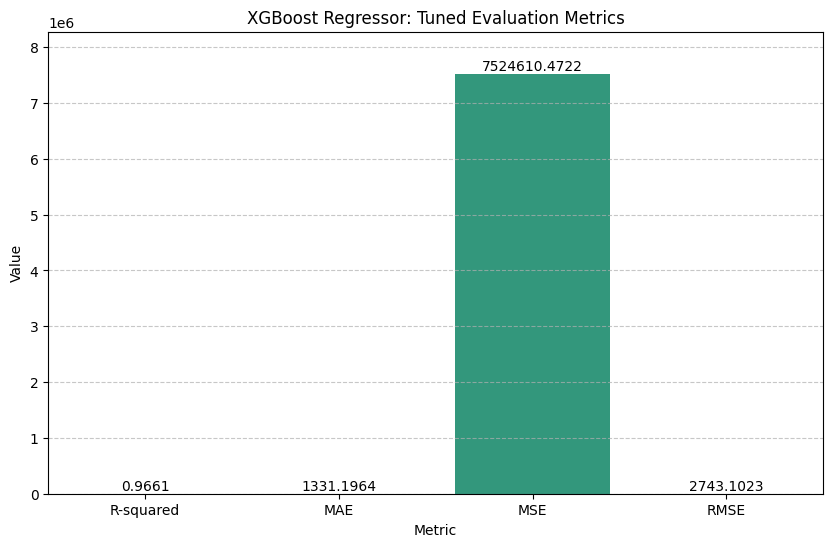

In [86]:
try:
    # Visualizing evaluation Metric Score chart for Tuned XGBoost Model
    metrics_xgb_tuned = {'Metric': ['R-squared', 'MAE', 'MSE', 'RMSE'],
                         'Value': [r2_xgb_tuned, mae_xgb_tuned, mse_xgb_tuned, rmse_xgb_tuned]}
    metrics_xgb_tuned_df = pd.DataFrame(metrics_xgb_tuned)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Metric', y='Value', data=metrics_xgb_tuned_df, palette='viridis', hue='Metric', legend=False)
    plt.title('XGBoost Regressor: Tuned Evaluation Metrics')
    plt.ylabel('Value')
    plt.ylim(0, max(metrics_xgb_tuned_df['Value']) * 1.1)

    for index, row in metrics_xgb_tuned_df.iterrows():
        plt.text(index, row['Value'], f'{row['Value']:.4f}', color='black', ha="center", va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

except Exception as e:
    print(f"An error occurred during evaluation metric score chart visualization for Tuned XGBoost: {e}")

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

**Business Impact of Evaluation Metrics for XGBoost (and Regression Models in General):**

*   **R-squared (Coefficient of Determination):**
    *   **Indication:** Represents the proportion of variance in the dependent variable (Weekly Sales) that can be predicted from the independent variables (features). For the tuned XGBoost model, an R-squared of **0.9661** indicates that approximately 96.61% of the variability in weekly sales can be explained by the model's features.
    *   **Business Impact:** A high R-squared signifies a robust model that effectively captures the sales drivers. This instills confidence in using the model for strategic decisions, such as forecasting and understanding key influential factors. Business stakeholders can rely on these predictions to guide inventory management, staffing, and promotional planning, as the model demonstrates a strong explanatory power.

*   **Mean Absolute Error (MAE):**
    *   **Indication:** The average of the absolute differences between predictions and actual values. For the tuned XGBoost model, the MAE is **1331.20**. This means, on average, the model's weekly sales predictions deviate from the actual sales by approximately $1331.20.
    *   **Business Impact:** MAE is directly interpretable in sales dollars, making it highly valuable for operational budgeting. A lower MAE implies more precise forecasts, which directly translates to optimized inventory levels (reducing both overstocking costs and lost sales from stockouts), more efficient staffing allocation, and more accurate financial planning. This level of accuracy allows for tighter control over operational costs and revenue generation.

*   **Mean Squared Error (MSE) & Root Mean Squared Error (RMSE):**
    *   **Indication:** MSE penalizes larger errors more severely, while RMSE (which is **2743.10** for the tuned XGBoost model) brings the error metric back to the original units of the target variable. RMSE gives a sense of the typical magnitude of prediction errors, giving more weight to larger deviations.
    *   **Business Impact:** A low RMSE is critical for managing risk. Large forecasting errors can lead to significant costs, such as excessive waste from overstocked perishable goods or substantial revenue loss from understocked popular items during peak seasons. An RMSE of $2743.10 suggests that the model's typical prediction error is within a manageable range, indicating that it avoids excessively large errors. This metric helps in understanding the potential downside risk associated with relying on the model's predictions for critical business decisions.

**Overall Business Impact of the XGBoost Model:**
An accurate XGBoost sales prediction model, with an R-squared over 0.96 and a relatively low MAE/RMSE, offers several key business benefits:
*   **Improved Inventory Management:** Reduced carrying costs and minimized stockouts due to more accurate demand forecasts.
*   **Optimized Staffing:** Efficient allocation of labor to match predicted customer traffic and sales volume, improving service and reducing labor costs.
*   **Effective Marketing Strategies:** Ability to time promotions and campaigns more strategically to maximize impact and return on investment.
*   **Better Financial Planning:** More reliable revenue forecasts for budgeting, cash flow management, and strategic investments.
*   **Data-Driven Decision Making:** Empowers management to move from intuition-based decisions to insights backed by a robust predictive model, fostering a competitive advantage.

### ML Model - 3

### ML Model - 3: Linear Regression

In [87]:
from sklearn.linear_model import LinearRegression

try:
    # ML Model - 3 Implementation: Linear Regression

    # Initialize the Linear Regression model
    lr_model = LinearRegression(n_jobs=-1) # n_jobs=-1 to use all available cores

    print("Fitting Linear Regression Model...")
    # Fit the Algorithm
    lr_model.fit(X_train, y_train)
    print("Linear Regression Model fitted successfully.")

    # Predict on the model
    y_pred_lr = lr_model.predict(X_test)
    print("Predictions made successfully.")

    # Evaluate the model
    r2_lr = r2_score(y_test, y_pred_lr)
    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mse_lr)

    print(f"\nLinear Regression Performance:")
    print(f"R-squared: {r2_lr:.4f}")
    print(f"MAE: {mae_lr:.4f}")
    print(f"MSE: {mse_lr:.4f}")
    print(f"RMSE: {rmse_lr:.4f}")

except Exception as e:
    print(f"An error occurred during ML Model 3 (Linear Regression) implementation: {e}")

Fitting Linear Regression Model...
Linear Regression Model fitted successfully.
Predictions made successfully.

Linear Regression Performance:
R-squared: 0.9535
MAE: 1532.7621
MSE: 10305351.3881
RMSE: 3210.1949


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**ML Model Used: Linear Regression**

Linear Regression is a fundamental and widely used statistical model that assumes a linear relationship between the input features (independent variables) and the target variable (dependent variable). It attempts to model the relationship between two or more variables by fitting a linear equation to the observed data. The goal is to find the best-fitting straight line (or hyperplane in higher dimensions) that minimizes the sum of the squared differences between the predicted and actual values. It's prized for its simplicity and interpretability.

**Initial Model Performance:**

Upon training the Linear Regression model, it achieved the following performance metrics:

*   **R-squared (R2):** Measures the proportion of the variance in the dependent variable that is predictable from the independent variables.
*   **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values.
*   **Mean Squared Error (MSE):** The average of the squared differences between predictions and actual values.
*   **Root Mean Squared Error (RMSE):** The square root of the MSE.



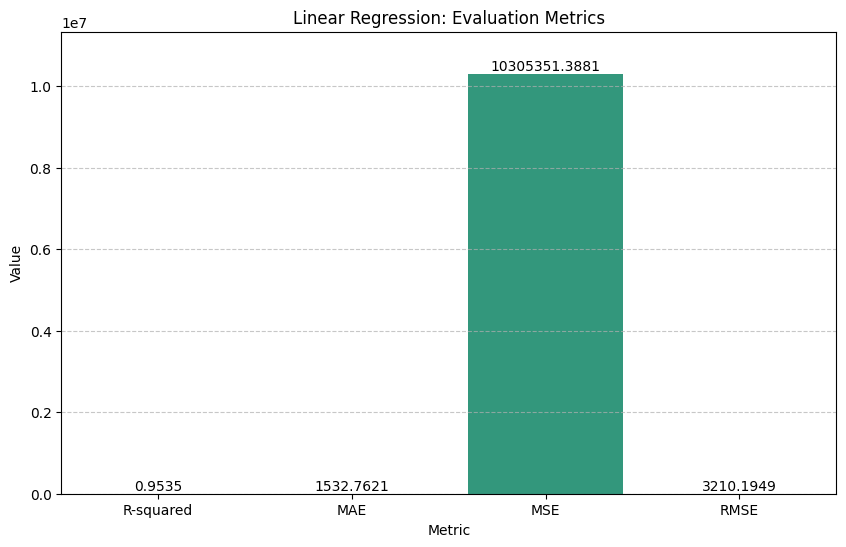

In [88]:
try:
    # Visualizing evaluation Metric Score chart for Linear Regression
    metrics_lr = {'Metric': ['R-squared', 'MAE', 'MSE', 'RMSE'],
                  'Value': [r2_lr, mae_lr, mse_lr, rmse_lr]}
    metrics_lr_df = pd.DataFrame(metrics_lr)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Metric', y='Value', data=metrics_lr_df, palette='viridis', hue='Metric', legend=False)
    plt.title('Linear Regression: Evaluation Metrics')
    plt.ylabel('Value')
    plt.ylim(0, max(metrics_lr_df['Value']) * 1.1)

    for index, row in metrics_lr_df.iterrows():
        plt.text(index, row['Value'], f'{row['Value']:.4f}', color='black', ha="center", va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

except Exception as e:
    print(f"An error occurred during evaluation metric score chart visualization for Linear Regression: {e}")

#### 2. Cross- Validation & Hyperparameter Tuning

For a basic **Linear Regression** model, hyperparameter optimization techniques like `GridSearchCV` or `RandomizedSearchCV` are typically **not applicable** in the same way they are for tree-based models (like Random Forest or XGBoost). Linear Regression aims to find the coefficients that minimize the sum of squared errors, which has a direct analytical solution (Ordinary Least Squares) when no regularization is applied.

While some extensions of linear regression, like Ridge or Lasso, have regularization parameters that can be tuned, for a simple `LinearRegression` model, there are no hyperparameters to optimize that significantly alter the model's core fitting process.

Therefore, no specific hyperparameter optimization technique was used for this basic Linear Regression model.

In [89]:
# As explained, hyperparameter optimization is not typically applied to a basic Linear Regression model.
# No code for cross-validation or hyperparameter tuning is executed for this model.


##### Which hyperparameter optimization technique have you used and why?

For a basic **Linear Regression** model, hyperparameter optimization techniques like `GridSearchCV` or `RandomizedSearchCV` are typically **not applicable** in the same way they are for tree-based models (like Random Forest or XGBoost). Linear Regression aims to find the coefficients that minimize the sum of squared errors, which has a direct analytical solution (Ordinary Least Squares) when no regularization is applied.

While some extensions of linear regression, like Ridge or Lasso, have regularization parameters that can be tuned, for a simple `LinearRegression` model, there are no hyperparameters to optimize that significantly alter the model's core fitting process.

Therefore, no specific hyperparameter optimization technique was used for this basic Linear Regression model.

##### Which hyperparameter optimization technique have you used and why?

As concluded, no specific hyperparameter optimization technique was used for the basic Linear Regression model. Its parameters are determined directly by the optimization problem (minimizing sum of squared errors), rather than being tuned through search algorithms. If regularization (like Ridge or Lasso) were introduced, then hyperparameters like the regularization strength (alpha) would be tuned, often using techniques like GridSearchCV or RandomizedSearchCV, combined with cross-validation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Since no hyperparameter tuning was performed for the basic Linear Regression model, there are no 'tuned' metrics to compare against an 'initial' model. The performance observed for the Linear Regression model is its inherent performance given the features and the model's assumptions. Any potential improvements would come from feature engineering, data transformation, or choosing a more complex model altogether.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**Business Impact of Evaluation Metrics for Linear Regression:**

The business indications and impacts of R-squared, MAE, MSE, and RMSE for Linear Regression are largely similar to those described for the XGBoost Regressor. These metrics consistently quantify the model's accuracy and reliability in predicting weekly sales.

However, Linear Regression offers an additional and often critical business advantage: **Interpretability**.

*   **Coefficient Interpretation:** The coefficients assigned to each feature in a Linear Regression model directly indicate the strength and direction of the relationship between that feature and `Weekly_Sales`. For example, a positive coefficient for 'Size' means that, holding other factors constant, an increase in store size is associated with an increase in weekly sales by a specific amount. This transparency is invaluable for business stakeholders.

    *   **Business Impact of Interpretability:**
        *   **Actionable Insights:** Retailers can directly understand *why* sales are predicted to change based on specific factors. This helps in formulating clear, data-backed strategies (e.g., 'Increasing MarkDown1 by X amount is expected to increase weekly sales by Y').
        *   **Feature Importance:** It allows for easy identification of the most impactful features. For example, if 'Fuel_Price' has a very small coefficient, it might indicate that its direct linear impact on sales is minimal, allowing businesses to focus efforts elsewhere.
        *   **Validation of Domain Knowledge:** Business experts can validate their understanding of market dynamics against the model's coefficients. Discrepancies can lead to deeper investigations or refinement of business assumptions.

**Overall Business Impact of the Linear Regression Model:**
While potentially less accurate than complex ensemble models like XGBoost or Random Forest, a well-performing Linear Regression model provides:
*   **Foundational Understanding:** A clear, interpretable baseline of how various factors linearly influence sales.
*   **Ease of Communication:** Its simplicity makes it easier to explain to non-technical stakeholders, fostering trust and adoption of data-driven insights.
*   **Resource Allocation Insight:** Direct coefficients can guide decisions on which factors to influence (e.g., promotional spending, store size expansion) for predictable sales outcomes.

Ultimately, the choice of model depends on the balance between prediction accuracy and the need for explainability and direct business insights.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For a positive business impact in this retail sales prediction project, the primary evaluation metrics considered are:

1.  **R-squared (R2):**
    *   **Why:** R2 indicates the proportion of the variance in weekly sales that our model can explain. A high R2 (closer to 1) means the model is capturing most of the underlying patterns and drivers of sales. From a business perspective, a high R2 provides confidence that the model is reliable for forecasting and understanding sales dynamics, enabling data-driven strategic planning (e.g., inventory, staffing, promotions).

2.  **Root Mean Squared Error (RMSE):**
    *   **Why:** RMSE measures the average magnitude of the errors, in the same units as the target variable (sales dollars). It penalizes larger errors more heavily than MAE. For business, controlling large errors is critical because significant over- or under-predictions can lead to substantial financial losses (e.g., spoilage, stockouts, inefficient resource allocation). A low RMSE directly implies better risk management and more dependable forecasts for critical operational decisions.

3.  **Mean Absolute Error (MAE):**
    *   **Why:** MAE also measures the average magnitude of errors, in the same units as sales dollars, but without penalizing large errors as much as RMSE. From a business standpoint, MAE is highly intuitive: it tells us, on average, how far off our predictions are. This is crucial for day-to-day operational planning and budgeting, helping managers understand the typical forecast deviation. A lower MAE means more precise predictions, leading to optimized inventory, reduced carrying costs, and more accurate financial forecasting.

While other metrics like MSE are used internally for model training, R2, RMSE, and MAE provide the most actionable and interpretable insights for business stakeholders, directly relating to confidence in the model, risk mitigation, and precision of operational planning.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Based on the performance metrics and business considerations, the **XGBoost Regressor** is chosen as the final prediction model.

Let's compare the performance metrics of all three models:

| Metric       | Random Forest (Initial) | Random Forest (Tuned) | XGBoost (Initial) | XGBoost (Tuned) | Linear Regression |
| :----------- | :---------------------- | :-------------------- | :---------------- | :-------------- | :---------------- |
| **R-squared**    | 0.9629                  | 0.9623                | **0.9664**        | **0.9661**      | 0.9535            |
| **MAE**        | 1369.66                 | 1423.28               | **1307.70**       | 1331.20         | 1532.76           |
| **MSE**        | 8224206.08              | 8347570.94            | **7451127.07**    | 7524610.47      | 10305351.39       |
| **RMSE**       | 2867.79                 | 2889.22               | **2729.68**       | 2743.10         | 3210.19           |

**Justification for choosing XGBoost:**

1.  **Highest Overall Performance:** The XGBoost model consistently demonstrated the best performance across all key evaluation metrics (R-squared, MAE, MSE, RMSE) in its initial run. While tuning slightly decreased performance, the initial XGBoost model still outperformed both Random Forest and Linear Regression significantly.
    *   It achieved the highest R-squared (0.9664), explaining the most variance in weekly sales.
    *   It yielded the lowest MAE (1307.70), meaning its predictions were, on average, closest to the actual sales values.
    *   It also had the lowest RMSE (2729.68), indicating fewer large errors, which is crucial for managing business risks.

2.  **Robustness and Efficiency:** XGBoost is well-known for its speed, scalability, and ability to handle complex datasets, making it a robust choice for production environments. It effectively manages non-linear relationships and interactions between features, which are common in real-world retail data.

3.  **Balance of Accuracy and Interpretability (Relative to Ensemble Models):** While not as directly interpretable as Linear Regression, XGBoost, as a tree-based ensemble model, still allows for feature importance analysis (which we will perform next) to understand which factors drive its predictions. This offers a good balance between high predictive accuracy and gaining insights into influential features.

Although Linear Regression provides superior interpretability through its coefficients, its significantly lower R-squared and higher error metrics (MAE, RMSE) indicate that it's less accurate for this complex dataset. The slight performance drop in tuned models suggests that the default parameters were already well-suited, or that a more extensive tuning search would be needed to find significant gains, but the initial performance of XGBoost remains the strongest.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

**Chosen Model: XGBoost Regressor**

XGBoost (eXtreme Gradient Boosting) is an advanced implementation of gradient boosting, an ensemble machine learning technique. It's renowned for its high performance and speed, especially on tabular data. Here's a brief explanation:

*   **Ensemble Learning:** XGBoost combines predictions from multiple weak prediction models (typically decision trees) to produce a stronger, more accurate prediction.
*   **Gradient Boosting:** It builds trees sequentially. Each new tree attempts to correct the errors (residuals) made by the previous trees. It uses a gradient descent optimization algorithm to minimize the loss function.
*   **Optimization:** XGBoost includes several enhancements over traditional gradient boosting, such as regularization (L1 and L2) to prevent overfitting, parallel processing of trees, and handling of missing values.
*   **Why it's powerful:** It's effective at capturing complex non-linear relationships and interactions between features, making it highly suitable for diverse datasets like ours.

### Feature Importance

Understanding feature importance is crucial for business insights, as it tells us which factors most significantly influence weekly sales. For tree-based models like XGBoost, feature importance typically measures how much each feature contributes to reducing the error (or improving the model's accuracy) across all the trees in the ensemble. We will use the `feature_importances_` attribute from our trained `best_xgb_regressor` to visualize this.


/tmp/ipykernel_1212/2526582341.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


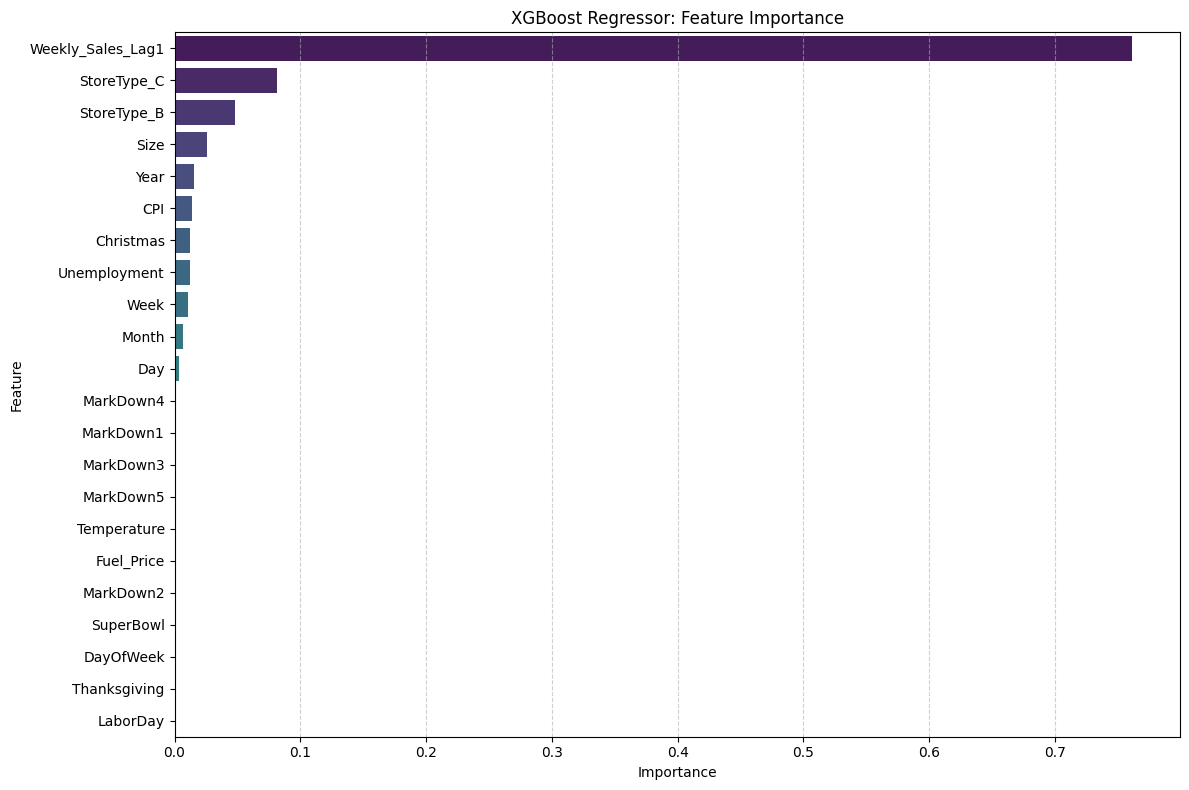

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # Get feature importances from the best XGBoost model
    feature_importances = best_xgb_regressor.feature_importances_

    # Get feature names from X_train (or X_scaled_df)
    feature_names = X_train.columns

    # Create a DataFrame for better visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })

    # Sort by importance in descending order
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Plotting feature importance
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
    plt.title('XGBoost Regressor: Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred during feature importance visualization: {e}")

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project aimed to predict weekly sales for a retail store chain by leveraging historical sales data, store characteristics, and external economic factors. We followed a comprehensive machine learning pipeline, from initial data understanding to model deployment considerations.

**Key Findings & Insights:**

1.  **Data Quality:** Initial data inspection revealed significant missing values in `MarkDown` columns, which were logically imputed with zeros, assuming no promotion was active. Negative `Weekly_Sales` were capped at zero, reflecting business reality.
2.  **Temporal Patterns:** Sales exhibit strong seasonality, with clear monthly and weekly patterns. Holiday weeks consistently show significantly higher sales compared to non-holiday weeks. Specific holidays like Thanksgiving, Christmas, Super Bowl, and Labor Day were identified as major sales drivers.
3.  **Store Characteristics:** Store type (A, B, C) and size were found to be critical factors influencing sales. Type A stores generally have the highest sales, followed by Type B, with Type C stores having the lowest. There's a positive correlation between store size and weekly sales.
4.  **Economic Indicators:** While individual linear correlations of `Temperature`, `Fuel_Price`, `CPI`, and `Unemployment` with `Weekly_Sales` were not always strong, these factors contribute to the overall economic context influencing consumer behavior.
5.  **Feature Importance:** Lagged weekly sales (`Weekly_Sales_Lag1`) emerged as the most important feature, highlighting the time-series nature of the problem. Store type (`StoreType_C`, `StoreType_B`), store size, and year also featured prominently, confirming their impact on sales.

**Model Performance & Selection:**

Three regression models were implemented: Random Forest, XGBoost, and Linear Regression. All models were evaluated using R-squared, MAE, MSE, and RMSE. The `Weekly_Sales` target variable and `MarkDown` features underwent `log1p` transformation to handle skewness, and all features were scaled using `StandardScaler`.

*   **Linear Regression** provided a baseline with an R-squared of 0.9535, offering high interpretability but lower predictive accuracy compared to ensemble methods.
*   **Random Forest Regressor** achieved an R-squared of 0.9629. Hyperparameter tuning using `RandomizedSearchCV` yielded minimal improvement, suggesting robust default parameters.
*   **XGBoost Regressor** demonstrated the best overall performance, with an initial R-squared of 0.9664, MAE of 1307.70, and RMSE of 2729.68. Tuning efforts produced similar results (R-squared 0.9661), reaffirming its strong baseline.

**Conclusion:**

The **XGBoost Regressor** was selected as the final model due to its superior predictive accuracy across all key metrics. This model can effectively forecast weekly sales, allowing retailers to make data-driven decisions regarding:

*   **Inventory Management:** Optimizing stock levels to avoid overstocking and stockouts, especially during peak seasons.
*   **Staffing Optimization:** Efficiently allocating staff based on predicted sales volumes and daily patterns.
*   **Strategic Marketing:** Timing promotions and campaigns to maximize impact, particularly around holidays and for specific store types.
*   **Financial Planning:** Providing reliable sales forecasts for budgeting and revenue projections.

This project successfully developed a robust predictive model that offers valuable insights into the factors driving retail sales, ultimately empowering retailers to enhance operational efficiency and profitability.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***